<a href="https://colab.research.google.com/github/crisromero-dev/SpotifyTrack_ML_EV1/blob/main/SpotifyTrack_ML_EV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligencia musical y prediccion de popularidad de canciones
## Analisis exploratorio y preparacion de datos - Spotify Tracks Dataset

**Asignatura:** MLY1101 - Machine Learning
**Evaluacion:** Parcial Nro. 1 - Presentacion y defensa tecnica del proyecto
**Caso:** C - Inteligencia musical y prediccion de popularidad de canciones (Spotify Tracks)
**Metodologia:** CRISP-DM (fases 1 a 3 y evaluacion de sesgos)

### Indice

1. Introduccion y contexto del problema
2. Acercamiento inicial a los datos
3. Analisis exploratorio de datos (EDA)
4. Preprocesamiento de datos
5. Sesgos, etica y privacidad
6. Conclusiones y proximos pasos

---
# 1. Introduccion y contexto del problema

## 1.1 Contexto y origen de los datos

Spotify es una de las plataformas de streaming musical mas utilizadas del mundo. Para cada cancion de su catalogo, la plataforma calcula un indice de **popularidad** (0 a 100) basado principalmente en la cantidad de reproducciones recientes, y un conjunto de **caracteristicas de audio** (*audio features*) obtenidas de forma algoritmica a partir de la señal sonora: que tan bailable es, su energia, su tempo, su positividad emocional, etc.

El dataset utilizado es el **Spotify Tracks Dataset**, publicado en Kaggle por el usuario *maharshipandya* (https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset). El autor lo construyo consultando la **Web API de Spotify** con Python: por cada uno de 114 generos musicales recupero aproximadamente 1.000 canciones junto con sus metadatos y caracteristicas de audio.

| Atributo | Valor |
|---|---|
| Registros | 114.000 filas |
| Columnas | 21 |
| Unidad de observacion | Una cancion recuperada al buscar un genero |
| Variable objetivo | `popularity` (entero de 0 a 100) |
| Origen | Web API de Spotify (datos de plataforma, no encuesta) |
| Formato | CSV |

Un detalle de construccion que condiciona todo el analisis: como las canciones se recuperaron **por genero**, una misma cancion puede aparecer varias veces si pertenece a mas de un genero. Esto se verifica en la seccion 2.

## 1.2 Problema de negocio

El proyecto aborda la siguiente pregunta: **¿es posible estimar la popularidad que alcanzara una cancion a partir de sus caracteristicas musicales y de metadatos basicos (genero, contenido explicito, duracion, colaboraciones)?** Una estimacion de este tipo serviria como herramienta de apoyo para priorizar canciones en campañas de promocion, detectar canciones con potencial no aprovechado y entender que atributos musicales se asocian con el exito en cada genero.

## 1.3 Tipo de problema

Se trata de un problema de **aprendizaje supervisado de regresion**: la variable objetivo `popularity` es numerica (0 a 100) y se dispone de ejemplos historicos etiquetados. Se descarto la formulacion como clasificacion binaria (popular / no popular) para no imponer un umbral arbitrario y conservar la informacion completa de la escala.

## 1.4 Objetivos del proyecto

**Objetivo general.** Preparar un conjunto de datos confiable, sin fuga de informacion y documentado, que permita entrenar un modelo de regresion para estimar la popularidad de una cancion en Spotify a partir de sus caracteristicas musicales y metadatos.

**Objetivos especificos.**

1. Caracterizar el dataset e identificar problemas de calidad: nulos, duplicados, valores invalidos y outliers.
2. Identificar mediante EDA las variables con mayor relacion con la popularidad y los patrones relevantes por genero.
3. Construir un pipeline de preparacion reproducible (limpieza, ingenieria de caracteristicas, codificacion, transformacion y escalado) que evite la fuga de datos entre entrenamiento y prueba.
4. Evaluar los sesgos, limitaciones y riesgos eticos del uso de estos datos antes de la etapa de modelado.

**Alcance.** Esta entrega cubre las fases de comprension del negocio, comprension de los datos y preparacion de los datos de CRISP-DM, ademas del analisis de sesgos. El entrenamiento y la optimizacion de modelos quedan para la siguiente etapa.

## 1.5 KPIs del proyecto

Los KPIs definen cuando el modelo de la siguiente etapa se considerara util. Varios umbrales se expresan **en relacion con un modelo de referencia (baseline)** que siempre predice la popularidad media del conjunto de entrenamiento; su valor numerico se calcula al final de la seccion 4, sobre el conjunto de prueba ya preparado.

| KPI | Que mide | Umbral de aceptacion |
|---|---|---|
| R^2 (test) | Proporcion de la variabilidad de la popularidad explicada por el modelo | >= 0,40 |
| RMSE (test) | Error que penaliza mas los errores grandes | <= 77% del RMSE del baseline |
| MAE (test) | Error absoluto medio, en puntos de popularidad | <= 80% del MAE del baseline |
| Brecha de R^2 train-test | Control de sobreajuste | <= 0,05 |
| MAE en canciones de alta popularidad (>= 70) | Calidad de la estimacion en el segmento de mayor interes comercial | <= 20 puntos |
| Brecha de MAE entre cuartiles de genero | Equidad: que el error no se concentre en los generos menos populares | <= 5 puntos |

Justificacion de los umbrales (calibrados con los hallazgos del EDA, siguiendo la naturaleza iterativa de CRISP-DM):

- **R^2 >= 0,40 y RMSE <= 77% del baseline son la misma exigencia vista de dos formas** (un R^2 de 0,40 equivale a un RMSE de aproximadamente 77% del baseline (la raiz cuadrada de 0,60)). El umbral se fija sobre el hallazgo de la seccion 5.2: el genero por si solo explica cerca del 35% de la varianza, asi que un modelo util debe aportar informacion adicional al genero, pero sin exigir un nivel irreal para un fenomeno que depende de factores ausentes en los datos (fama del artista, marketing, playlists editoriales).
- **MAE <= 80% del baseline** asegura que la mejora no se concentre solo en reducir unos pocos errores grandes.
- **El KPI de alta popularidad** existe porque la linea base comete un error de mas de 40 puntos en ese segmento (seccion 4.12): un error promedio aceptable puede esconder que el modelo falla justamente donde el negocio decide sus inversiones. Bajar a 20 puntos implica reducir ese error a menos de la mitad.
- **El KPI de equidad** responde a la evidencia de la seccion 4.12: la linea base ya comete errores desiguales entre grupos de generos, y un modelo que no corrija esa brecha reproduciria el sesgo de que algunos generos son sistematicamente mas dificiles de predecir que otros.

## 1.6 Metodologia: CRISP-DM

| Fase | Aplicacion en este proyecto | Seccion |
|---|---|---|
| 1. Comprension del negocio | Problema, objetivos y KPIs | 1 |
| 2. Comprension de los datos | Glosario, calidad de datos, EDA univariado y bivariado | 2, 3 |
| 3. Preparacion de los datos | Limpieza, deduplicacion, ingenieria de caracteristicas, division, codificacion y escalado | 4 |
| 4. Modelado | Fuera del alcance de esta entrega | 6 |
| 5. Evaluacion | KPIs definidos y auditoria de sesgos de los datos | 1.5, 5 |
| 6. Despliegue | Fuera del alcance | - |

CRISP-DM es iterativo: varias decisiones de preparacion (seccion 4) surgieron de hallazgos del EDA que obligaron a volver a revisar la calidad de los datos, en particular la estructura de duplicados por genero.

---
# 2. Acercamiento inicial a los datos

## 2.1 Librerias y configuracion general

In [ ]:
# Manipulacion de datos
import numpy as np
import pandas as pd

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Preparacion de datos y utilidades de scikit-learn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, PowerTransformer, TargetEncoder
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Semilla unica para que todos los resultados aleatorios sean reproducibles
SEMILLA = 42

# Estilo general de los graficos
sns.set_theme(style='whitegrid')
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 11
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

# Colores usados de forma consistente en todo el notebook
COLOR_OBJETIVO = '#1DB954'   # verde Spotify para la variable objetivo
COLOR_AUDIO = '#4C72B0'      # azul para caracteristicas de audio
COLOR_ALERTA = '#C44E52'     # rojo para problemas de calidad / outliers
COLOR_NEUTRO = '#8C8C8C'     # gris para referencias

# El notebook no crea carpetas ni guarda archivos en disco: todo el trabajo
# queda en memoria durante la sesion de Colab.

## 2.2 Carga de datos

El archivo `Spotify_Tracks_Dataset.csv` debe estar subido en el entorno de Colab (mismo directorio que el notebook, por ejemplo `/content/`).

In [ ]:
df = pd.read_csv('Spotify_Tracks_Dataset.csv')
print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dimensiones: 114,000 filas x 21 columnas


## 2.3 Primeras observaciones y tipos de datos

In [ ]:
# Primeras filas del dataset
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic


In [ ]:
# Tipo de dato y cantidad de valores no nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

**Interpretacion.**

- El dataset tiene 114.000 filas y 21 columnas: 5 de texto, 9 decimales, 6 enteras y 1 booleana.
- Solo 3 columnas tienen nulos (`artists`, `album_name`, `track_name`), con un unico valor faltante cada una.
- El tipo de dato almacenado no siempre coincide con la naturaleza de la variable. `key`, `mode` y `time_signature` estan guardadas como enteros, pero son categorias musicales: un tono 6 no es "el doble" que un tono 3. `explicit` es booleana y debera convertirse a 0/1 para el modelado.
- `Unnamed: 0` no aparece en la documentacion del dataset; se revisa en la seccion 2.8.2.

## 2.4 Glosario de variables

Definiciones basadas en la documentacion de la Web API de Spotify y en la descripcion del dataset en Kaggle.

| Variable | Descripcion | Rango / valores | Tipo |
|---|---|---|---|
| `Unnamed: 0` | Indice de fila exportado junto al CSV; no es un atributo de la cancion | 0 - 113.999 | Identificador (artefacto) |
| `track_id` | Identificador unico de la cancion en Spotify | Texto de 22 caracteres | Identificador |
| `artists` | Artista(s) que interpretan la cancion; si son varios se separan con `;` | Texto | Texto libre |
| `album_name` | Nombre del album en que aparece la cancion | Texto | Texto libre |
| `track_name` | Titulo de la cancion | Texto | Texto libre |
| `popularity` | Popularidad calculada por Spotify, basada principalmente en el numero de reproducciones recientes | 0 - 100 | **Variable objetivo** (numerica discreta) |
| `duration_ms` | Duracion de la cancion en milisegundos | >= 0 | Numerica continua |
| `explicit` | Indica si la cancion tiene letras explicitas | True / False | Binaria |
| `danceability` | Que tan apta es para bailar, segun tempo, estabilidad ritmica y regularidad del pulso | 0,0 - 1,0 | Numerica continua |
| `energy` | Intensidad y actividad percibida (volumen, rapidez, ruido) | 0,0 - 1,0 | Numerica continua |
| `key` | Tonalidad musical en notacion de clases de altura (0 = Do, 1 = Do#, ..., 11 = Si); -1 si no se detecta | 0 - 11 | Categorica nominal (codificada como entero) |
| `loudness` | Volumen promedio de la cancion en decibelios (dB) | Aprox. -60 a 0 | Numerica continua |
| `mode` | Modalidad de la tonalidad | 1 = mayor, 0 = menor | Binaria |
| `speechiness` | Presencia de palabra hablada. Sobre 0,66 suele ser contenido casi solo hablado; entre 0,33 y 0,66 mezcla musica y habla (p. ej. rap) | 0,0 - 1,0 | Numerica continua |
| `acousticness` | Confianza de que la cancion sea acustica | 0,0 - 1,0 | Numerica continua |
| `instrumentalness` | Probabilidad de que la cancion no tenga voz; sobre 0,5 se considera instrumental | 0,0 - 1,0 | Numerica continua |
| `liveness` | Probabilidad de que la grabacion sea en vivo; sobre 0,8 es muy probable | 0,0 - 1,0 | Numerica continua |
| `valence` | Positividad musical (alegre / euforica frente a triste / tensa) | 0,0 - 1,0 | Numerica continua |
| `tempo` | Tempo estimado en pulsos por minuto (BPM) | > 0 | Numerica continua |
| `time_signature` | Compas estimado (cuantos pulsos por compas) | Documentado de 3 a 7 | Categorica ordinal (codificada como entero) |
| `track_genre` | Genero con el que se recupero la cancion | 114 categorias | Categorica nominal |

## 2.5 Clasificacion de las variables

A partir del glosario se agrupan las columnas segun su rol. Esta clasificacion se usa en todo el notebook para aplicar a cada grupo el analisis y el tratamiento que corresponde.

In [ ]:
# Agrupacion de columnas segun su naturaleza (definida a partir del glosario)
col_identificadores = ['Unnamed: 0', 'track_id']
col_texto = ['artists', 'album_name', 'track_name']
col_objetivo = 'popularity'
col_continuas = ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness',
                 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
col_discretas = ['explicit', 'mode', 'key', 'time_signature']
col_categorica = 'track_genre'

resumen_tipos = pd.DataFrame({
    'grupo': ['Identificadores', 'Texto libre', 'Objetivo', 'Continuas', 'Discretas / binarias', 'Categorica'],
    'cantidad': [len(col_identificadores), len(col_texto), 1, len(col_continuas), len(col_discretas), 1],
})
resumen_tipos

,grupo,cantidad
0,Identificadores,2
1,Texto libre,3
2,Objetivo,1
3,Continuas,10
4,Discretas / binarias,4
5,Categorica,1


## 2.6 Estadisticas descriptivas de las variables numericas

Se agrega la asimetria (*skewness*) porque ayuda a decidir mas adelante que variables necesitan transformacion.

In [ ]:
# Estadisticas descriptivas de la variable objetivo y las continuas
descriptivas = df[[col_objetivo] + col_continuas].describe().T
descriptivas['asimetria'] = df[[col_objetivo] + col_continuas].skew()
descriptivas

,count,mean,std,min,25%,50%,75%,max,asimetria
popularity,114000.000,33.239,22.305,0.000,17.000,35.000,50.000,100.000,0.046
duration_ms,114000.000,228029.153,107297.713,0.000,174066.000,212906.000,261506.000,5237295.000,11.195
danceability,114000.000,0.567,0.174,0.000,0.456,0.580,0.695,0.985,-0.399
energy,114000.000,0.641,0.252,0.000,0.472,0.685,0.854,1.000,-0.597
loudness,114000.000,-8.259,5.029,-49.531,-10.013,-7.004,-5.003,4.532,-2.007
speechiness,114000.000,0.085,0.106,0.000,0.036,0.049,0.085,0.965,4.648
acousticness,114000.000,0.315,0.333,0.000,0.017,0.169,0.598,0.996,0.727
instrumentalness,114000.000,0.156,0.310,0.000,0.000,0.000,0.049,1.000,1.734
liveness,114000.000,0.214,0.190,0.000,0.098,0.132,0.273,1.000,2.106
valence,114000.000,0.474,0.259,0.000,0.260,0.464,0.683,0.995,0.115


**Interpretacion.**

- **`popularity`** tiene media 33,2, mediana 35 y desviacion 22,3, con valores en todo el rango 0-100. Su asimetria es practicamente nula (0,05), por lo que **no requiere transformacion**. El primer cuartil (17) es bajo en relacion con la mediana, lo que anticipa un grupo importante de valores en 0 (seccion 3.1).
- **`duration_ms`** tiene un minimo de 0 (imposible para una cancion) y un maximo de 5.237.295 ms (87 minutos). Su asimetria de 11,2 indica una cola derecha extrema.
- **`speechiness` (4,6), `liveness` (2,1), `loudness` (-2,0) e `instrumentalness` (1,7)** estan fuertemente sesgadas. En `instrumentalness` la mediana es 0, es decir, mas de la mitad de las canciones tiene voz con total certeza.
- **`tempo`** tiene minimo 0 BPM, un valor que no corresponde a musica (seccion 2.8.5).
- **`loudness`** llega a +4,5 dB, sobre el 0 dB de referencia habitual.
- Las variables de escala [0, 1] respetan su rango documentado.
- **Las escalas son muy distintas** (milisegundos, decibelios negativos, BPM y proporciones), lo que anticipa la necesidad de escalado.

## 2.7 Variables categoricas y de texto

In [ ]:
# Cantidad de valores distintos en las columnas no numericas
for col in col_texto + [col_categorica, 'track_id']:
    print(f'{col:12s}: {df[col].nunique():>6,} valores unicos')

print('\nValores posibles de las variables discretas:')
for col in col_discretas:
    print(f'{col:15s}: {sorted(df[col].unique().tolist())}')

artists     : 31,437 valores unicos
album_name  : 46,589 valores unicos
track_name  : 73,608 valores unicos
track_genre :    114 valores unicos
track_id    : 89,741 valores unicos

Valores posibles de las variables discretas:
explicit       : [False, True]
mode           : [0, 1]
key            : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
time_signature : [0, 1, 3, 4, 5]


In [ ]:
# Cantidad de canciones por genero en el archivo original
canciones_por_genero = df[col_categorica].value_counts()
print(f'Generos: {canciones_por_genero.size}')
print(f'Minimo por genero: {canciones_por_genero.min()} | Maximo por genero: {canciones_por_genero.max()}')

Generos: 114
Minimo por genero: 1000 | Maximo por genero: 1000


**Interpretacion.**

- **Texto libre.** `artists` (31.437 valores), `album_name` (46.589) y `track_name` (73.608) tienen una cardinalidad tan alta que no pueden usarse directamente como predictores. Sirven para identificar canciones y para el analisis de sesgos.
- **`track_id`** tiene 89.741 valores unicos para 114.000 filas: hay canciones repetidas (seccion 2.8.3).
- **`track_genre`** tiene exactamente 1.000 canciones en cada uno de sus 114 generos. Esta uniformidad es una decision de diseño del autor, no un reflejo del catalogo real de Spotify, y tiene consecuencias de representatividad (seccion 5.1).
- **Variables discretas.** `time_signature` incluye los valores 0 y 1, fuera del rango documentado (3 a 7). `key` no presenta el valor -1 (tono no detectado).

## 2.8 Calidad de los datos

### 2.8.1 Valores nulos

In [ ]:
# Conteo de nulos por columna (solo columnas con al menos un nulo)
nulos = df.isnull().sum()
print(nulos[nulos > 0])

# Detalle de las filas que tienen algun nulo
df[df.isnull().any(axis=1)]

artists       1
album_name    1
track_name    1
dtype: int64


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.460,0,0.060,0.690,0.004,0.075,0.734,138.391,4,k-pop


**Interpretacion.** Los tres nulos pertenecen a **una sola fila** (indice 65900, genero `k-pop`). Esa fila tiene ademas `duration_ms = 0` y `popularity = 0`: es un registro defectuoso, no una cancion con informacion incompleta.

Como los campos faltantes son identificadores de texto que no pueden estimarse y representan menos del 0,001% del dataset, **la decision es eliminar la fila** (seccion 4.2) en lugar de imputar.

### 2.8.2 Duplicados exactos

`df.duplicated()` compara filas completas. Hay que revisar si la columna `Unnamed: 0` esta ocultando duplicados, ya que al ser un indice distinto en cada fila impide que dos filas sean identicas.

In [ ]:
# ¿Unnamed: 0 es simplemente el numero de fila?
print('Unnamed: 0 coincide con el indice:', (df['Unnamed: 0'] == df.index).all())

# Duplicados considerando todas las columnas vs. excluyendo el indice exportado
print('Duplicados con todas las columnas     :', df.duplicated().sum())
print('Duplicados sin la columna Unnamed: 0  :', df.drop(columns='Unnamed: 0').duplicated().sum())

Unnamed: 0 coincide con el indice: True


Duplicados con todas las columnas     : 0


Duplicados sin la columna Unnamed: 0  : 450


**Interpretacion.** `Unnamed: 0` es identica al indice de la fila: es un artefacto de la exportacion del CSV.

Al estar incluida, cada fila es unica y `df.duplicated()` reporta 0 duplicados. Al excluirla aparecen **450 filas completamente duplicadas**. Este es un error de diagnostico facil de cometer: la version anterior de este notebook concluia que no existian duplicados por esta razon.

**Decision:** eliminar `Unnamed: 0` y luego los duplicados exactos (secciones 4.1 y 4.2).

### 2.8.3 Canciones repetidas en varios generos

`track_id` deberia identificar una unica cancion. Si tiene menos valores unicos que filas, la misma cancion aparece mas de una vez.

In [ ]:
# Numero de veces que aparece cada cancion
copias_por_cancion = df.groupby('track_id').size()
print(f'Canciones distintas            : {copias_por_cancion.size:,}')
print(f'Filas que repiten una cancion  : {df.shape[0] - copias_por_cancion.size:,}')
print('\nDistribucion del numero de apariciones por cancion:')
print(copias_por_cancion.value_counts().sort_index())

# ¿Las copias de una cancion tienen las mismas caracteristicas de audio?
variables_por_cancion = df.groupby('track_id')[col_continuas + ['explicit', 'key', 'mode', 'time_signature']].nunique()
print('\nCanciones cuyas copias difieren en alguna caracteristica de audio:',
      (variables_por_cancion.max(axis=1) > 1).sum())

# ¿Y en popularidad o genero?
generos_distintos = df.groupby('track_id')['track_genre'].nunique()
popularidad_por_cancion = df.groupby('track_id')['popularity'].agg(['min', 'max'])
diferencia_pop = popularidad_por_cancion['max'] - popularidad_por_cancion['min']
print('Canciones con mas de un genero                    :', (generos_distintos > 1).sum())
print('Canciones con popularidad distinta entre copias   :', (diferencia_pop > 0).sum())
print('Diferencia mediana de popularidad en esos casos   :', diferencia_pop[diferencia_pop > 0].median())

Canciones distintas            : 89,741
Filas que repiten una cancion  : 24,259

Distribucion del numero de apariciones por cancion:
1    73100
2    11712
3     2984
4     1372
5      431
6      117
7       22
8        2
9        1
Name: count, dtype: int64



Canciones cuyas copias difieren en alguna caracteristica de audio: 0


Canciones con mas de un genero                    : 16299
Canciones con popularidad distinta entre copias   : 720
Diferencia mediana de popularidad en esos casos   : 1.0


In [ ]:
# Pares de generos que comparten mas canciones
generos_cancion = df[['track_id', 'track_genre']]
pares = generos_cancion.merge(generos_cancion, on='track_id')
# Se conserva cada par una sola vez (orden alfabetico) y se excluye el par de un genero consigo mismo
pares = pares[pares['track_genre_x'] < pares['track_genre_y']]
pares_frecuentes = pares.groupby(['track_genre_x', 'track_genre_y']).size().sort_values(ascending=False)
pares_frecuentes.head(10)

track_genre_x      track_genre_y
singer-songwriter  songwriter       1000
reggae             reggaeton         804
latino             reggaeton         745
dub                dubstep           728
punk               punk-rock         629
edm                house             629
latino             reggae            623
latin              latino            605
alt-rock           alternative       594
indie              indie-pop         580
dtype: int64

**Interpretacion.** Este es el principal problema de calidad del dataset.

- **Magnitud.** Hay 89.741 canciones distintas y 24.259 filas extra (21,3% del archivo) que repiten una cancion ya presente. 16.299 canciones aparecen en mas de un genero, algunas hasta en 9.
- **Las copias son la misma grabacion.** En el 100% de los casos todas las caracteristicas de audio son identicas entre copias. Solo cambia la etiqueta de genero y, en 720 canciones, la popularidad, con una diferencia mediana de apenas 1 punto (atribuible a que las consultas se hicieron en momentos distintos).
- **Las etiquetas de genero se solapan.**
  - `singer-songwriter` y `songwriter` comparten sus 1.000 canciones: son la misma etiqueta duplicada.
  - `reggae` y `reggaeton` comparten 804 canciones, aunque musicalmente son estilos distintos.
  - Esto muestra que el genero proviene de resultados de busqueda y no de una clasificacion musical rigurosa.

**Implicancias para el modelado:**

1. Fuga de datos si una copia queda en entrenamiento y otra en prueba.
2. Sobrepeso de las canciones que cruzan generos.
3. Ruido en la etiqueta de genero.

Se resuelve en la seccion 4.3.

### 2.8.4 Versiones distintas de una misma cancion

Ademas de las copias por genero (mismo `track_id`), Spotify puede tener la misma cancion publicada varias veces con identificadores distintos (single, album, recopilatorio, reedicion).

In [ ]:
# Se trabaja sobre una fila por track_id solo para este diagnostico
canciones_unicas = df.drop_duplicates(subset='track_id')

versiones = canciones_unicas.duplicated(subset=['artists', 'track_name'], keep=False)
print(f'Canciones con mas de una version (mismo artista y titulo): {versiones.sum():,}')

# ¿Coinciden tambien en duracion? Sirve para confirmar que son la misma grabacion
misma_duracion = canciones_unicas.duplicated(subset=['artists', 'track_name', 'duration_ms'], keep=False)
print(f'De ellas, con la misma duracion exacta                   : {misma_duracion.sum():,}')

# Ejemplo de una cancion con varias versiones
ejemplo = canciones_unicas[versiones].sort_values(['artists', 'track_name']).head(6)
ejemplo[['track_id', 'artists', 'track_name', 'album_name', 'popularity', 'duration_ms']]

Canciones con mas de una version (mismo artista y titulo): 13,054
De ellas, con la misma duracion exacta                   : 10,000


,track_id,artists,track_name,album_name,popularity,duration_ms
58516,5h7RBt7uQCF788tr9Zy92j,(Hed) P.E.,Crazy Legs,Broke,25,242800
58857,5igKQzi92vVl9Pjj86d42O,(Hed) P.E.,Crazy Legs,Broke,22,242960
58306,7kv31DonKok7StOsCdvoBT,(Hed) P.E.,Waiting to Die,Broke,27,194800
58874,0aiP8ezzmk3W1GRvnQYDCA,(Hed) P.E.,Waiting to Die,Broke,22,194626
46055,4Fqm5rqB0WMx0hPOwgRjFr,2 Brothers On The 4th Floor,Dreams (Will Come Alive),Dreams,65,264000
46065,2jzxWQlR0pZ2IUvk95nsfX,2 Brothers On The 4th Floor,Dreams (Will Come Alive),Dreams (Will Come Alive),28,263162


**Interpretacion.** 13.054 canciones comparten artista y titulo con otra que tiene distinto `track_id`, y 10.000 de ellas tienen exactamente la misma duracion que su par, lo que confirma que son la misma grabacion publicada en distintos lanzamientos. Los ejemplos lo ilustran:

- *(Hed) P.E.* tiene dos entradas del album *Broke*, con popularidad 25 y 22.
- *Dreams (Will Come Alive)* tiene popularidad 65 en su album y 28 en su single.

A diferencia del caso anterior, **estas filas no son errores**: son productos distintos del catalogo, cada uno con su propia popularidad. Por eso no se eliminan en bloque. Aun asi, generan dos riesgos:

- **Fuga de datos**, que se resuelve con una division agrupada (seccion 4.9).
- **Popularidades en 0 artificiales**, que se analizan en la seccion 3.1.1.

### 2.8.5 Valores fuera de rango o invalidos

Se contrastan los valores con los rangos definidos en el glosario.

In [ ]:
# Variables cuyo rango documentado es [0, 1]
col_proporcion = ['danceability', 'energy', 'speechiness', 'acousticness',
                  'instrumentalness', 'liveness', 'valence']

chequeos = {
    'duration_ms == 0': (df['duration_ms'] == 0).sum(),
    'tempo == 0 BPM': (df['tempo'] == 0).sum(),
    'time_signature == 0': (df['time_signature'] == 0).sum(),
    'time_signature == 1 (bajo el rango 3-7)': (df['time_signature'] == 1).sum(),
    'loudness > 0 dB': (df['loudness'] > 0).sum(),
    'speechiness > 0.66 (casi solo habla)': (df['speechiness'] > 0.66).sum(),
    'variables [0,1] fuera de rango': (~df[col_proporcion].apply(lambda s: s.between(0, 1))).sum().sum(),
    'popularity == 0': (df['popularity'] == 0).sum(),
}
pd.Series(chequeos, name='filas afectadas')

duration_ms == 0                               1
tempo == 0 BPM                               157
time_signature == 0                          163
time_signature == 1 (bajo el rango 3-7)      973
loudness > 0 dB                               90
speechiness > 0.66 (casi solo habla)         880
variables [0,1] fuera de rango                 0
popularity == 0                            16020
Name: filas afectadas, dtype: int64

In [ ]:
# ¿Que tipo de contenido tiene tempo = 0 o time_signature = 1?
print('Generos con tempo = 0:')
print(df.loc[df['tempo'] == 0, 'track_genre'].value_counts().head(5))
print('\nTempo = 0 que ademas tienen time_signature = 0:',
      ((df['tempo'] == 0) & (df['time_signature'] == 0)).sum())
print('\nGeneros con time_signature = 1:')
print(df.loc[df['time_signature'] == 1, 'track_genre'].value_counts().head(6))
print('\nValores de loudness positivos (resumen):')
print(df.loc[df['loudness'] > 0, 'loudness'].describe()[['count', 'mean', 'max']])

print('\nGeneros con speechiness > 0.66 (casi solo habla):')
print(df.loc[df['speechiness'] > 0.66, 'track_genre'].value_counts().head(6))
duracion_hablado = df.loc[df['speechiness'] > 0.66, 'duration_ms'] / 60000
print(f'\nDuracion mediana de ese contenido: {duracion_hablado.median():.2f} min '
      f'(la del dataset completo es {(df["duration_ms"] / 60000).median():.2f} min)')

Generos con tempo = 0:
track_genre
sleep          138
guitar           4
iranian          4
ambient          3
world-music      3
Name: count, dtype: int64

Tempo = 0 que ademas tienen time_signature = 0: 157

Generos con time_signature = 1:
track_genre
sleep        57
comedy       56
classical    42
ambient      39
grindcore    36
folk         30
Name: count, dtype: int64

Valores de loudness positivos (resumen):
count   90.000
mean     0.685
max      4.532
Name: loudness, dtype: float64

Generos con speechiness > 0.66 (casi solo habla):
track_genre
comedy        767
kids           11
children       10
show-tunes     10
funk            9
jazz            5
Name: count, dtype: int64



Duracion mediana de ese contenido: 3.24 min (la del dataset completo es 3.55 min)


**Interpretacion.**

- **`duration_ms = 0` (1 fila)** es la misma fila con nulos de la seccion 2.8.1.
- **`tempo = 0` (157 filas).** El 88% pertenece a `sleep`, y las 157 tienen tambien `time_signature = 0`. Corresponden a ruido blanco y sonidos para dormir, donde el algoritmo de Spotify no encontro pulso ritmico. Sus caracteristicas de audio no son confiables y el contenido no es musica en sentido estricto.
- **`time_signature = 0` (163 filas).** 157 coinciden con el caso anterior; el resto son casos aislados.
- **`time_signature = 1` (973 filas).** Aunque esta fuera del rango documentado, se concentra en `sleep`, `comedy`, `classical`, `ambient` y `grindcore`, generos sin metrica regular o con metricas cambiantes. Se interpreta como "compas irregular" mas que como un error.
- **`loudness > 0 dB` (90 filas).** Tienen una media de 0,69 dB y un maximo de 4,53 dB. Son valores levemente positivos, fisicamente posibles en masterizaciones muy comprimidas.
- **`popularity = 0` (16.020 filas, 14%).** Es un grupo demasiado grande para descartarlo sin analisis; se estudia en la seccion 3.1.1.
- **`speechiness > 0,66` (876 filas).** Segun la documentacion de Spotify, este umbral marca contenido hecho casi enteramente de palabra hablada, no musica. El 87% de estos casos (764 filas) pertenece al genero `comedy`, con stand-up y sketches. Su duracion mediana es de 3,2 minutos, practicamente igual a la del resto del dataset (3,55 min), asi que no se trata de contenido tipo podcast largo, sino de bits de comedia cortados al formato de una cancion. El 23% restante de `comedy` (232 filas) tiene `speechiness` bajo y son canciones reales con estructura musical (por ejemplo, parodias musicales de Lil Dicky o The Lonely Island), por lo que no conviene eliminar el genero completo, solo las filas que superan el umbral.

### 2.8.6 Resumen de problemas de calidad detectados

| Problema | Magnitud | Tratamiento propuesto | Seccion |
|---|---|---|---|
| Columna de indice exportada (`Unnamed: 0`) | 1 columna | Eliminar | 4.1 |
| Fila con nulos y duracion 0 | 1 fila | Eliminar | 4.2 |
| Duplicados exactos (ocultos por el indice) | 450 filas | Eliminar | 4.2 |
| Etiqueta de genero duplicada (`songwriter`) | 1.000 filas | Unificar con `singer-songwriter` | 4.3 |
| Misma cancion en varios generos | 24.259 filas extra | Una fila por cancion | 4.3 |
| Popularidad distinta entre copias | 720 canciones | Promedio entre copias | 4.3 |
| `tempo = 0` (contenido no musical) | 157 filas | Eliminar | 4.4 |
| `time_signature = 0` | 163 filas (157 coinciden con `tempo = 0`) | Eliminar junto a `tempo = 0`; imputar el resto con la moda | 4.4 |
| `time_signature = 1` | 973 filas | Conservar como compas irregular | 4.4, 4.7 |
| Contenido casi enteramente hablado (`speechiness > 0,66`) | 876 filas (87% del genero `comedy`) | Eliminar | 4.4 |
| Versiones distintas de una misma cancion | 13.054 canciones | Division train/test agrupada | 4.9 |
| `popularity = 0` | 16.020 filas | Analizar antes de decidir | 3.1.1, 4.5 |

---
# 3. Analisis exploratorio de datos (EDA)

El EDA se realiza sobre el archivo original, sin modificarlo. En los analisis donde las copias por genero distorsionarian el resultado (por ejemplo, contar canciones), se usa la vista `canciones_unicas` creada en la seccion 2.8.4, que tiene una fila por `track_id`. Cada bloque responde a una pregunta concreta y termina con su implicancia para la preparacion de datos.

## 3.1 Variable objetivo: `popularity`

**Pregunta:** ¿como se distribuye la popularidad y que significa el grupo de canciones con valor 0?

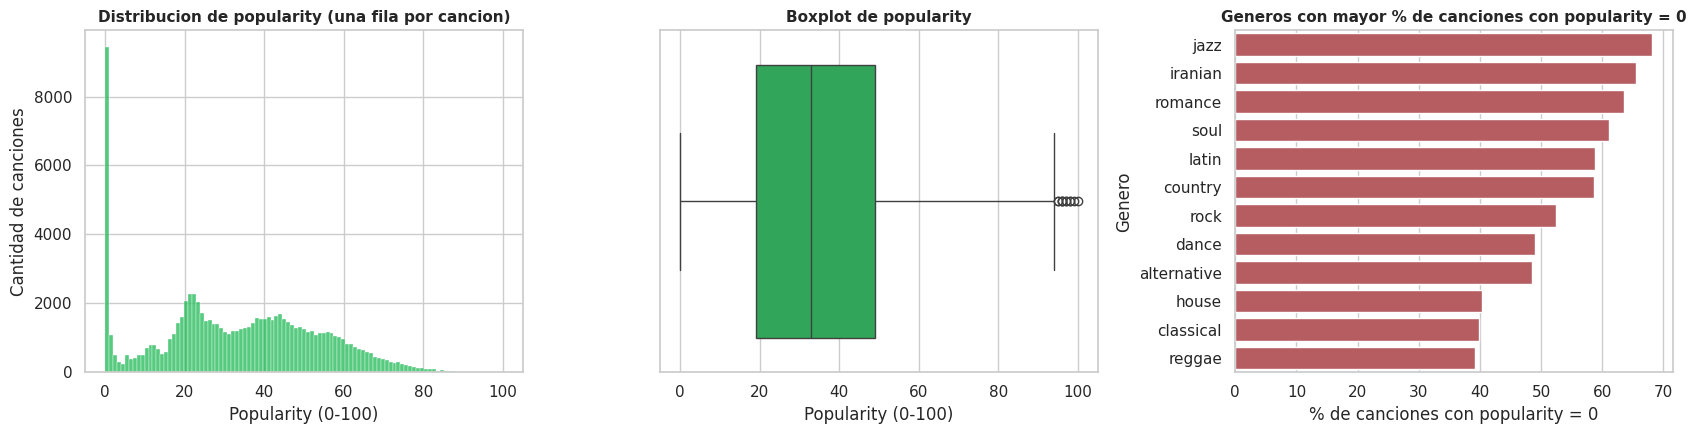

count   89741.000
mean       33.200
std        20.580
min         0.000
25%        19.000
50%        33.000
75%        49.000
max       100.000
Name: popularity, dtype: float64

Canciones con popularity = 0: 9,448 (10.5%)
Asimetria: 0.071


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Histograma de popularidad (una barra por cada valor entero)
sns.histplot(canciones_unicas['popularity'], bins=101, color=COLOR_OBJETIVO, ax=axes[0])
axes[0].set_title('Distribucion de popularity (una fila por cancion)')
axes[0].set_xlabel('Popularity (0-100)')
axes[0].set_ylabel('Cantidad de canciones')

# Boxplot horizontal para ver mediana, rango intercuartilico y extremos
sns.boxplot(x=canciones_unicas['popularity'], color=COLOR_OBJETIVO, ax=axes[1])
axes[1].set_title('Boxplot de popularity')
axes[1].set_xlabel('Popularity (0-100)')
axes[1].set_ylabel('')

# Porcentaje de canciones con popularidad 0 en los generos mas afectados
# Se calcula sobre el archivo original (una fila por cancion y genero), porque en la vista
# canciones_unicas cada cancion conserva solo uno de sus generos
pct_ceros = df.assign(es_cero=df['popularity'] == 0).groupby('track_genre')['es_cero'].mean() * 100
top_ceros = pct_ceros.sort_values(ascending=False).head(12)
sns.barplot(x=top_ceros.values, y=top_ceros.index, color=COLOR_ALERTA, ax=axes[2])
axes[2].set_title('Generos con mayor % de canciones con popularity = 0')
axes[2].set_xlabel('% de canciones con popularity = 0')
axes[2].set_ylabel('Genero')

plt.tight_layout()
plt.show()

print(canciones_unicas['popularity'].describe().round(2))
print(f"\nCanciones con popularity = 0: {(canciones_unicas['popularity'] == 0).sum():,} "
      f"({(canciones_unicas['popularity'] == 0).mean() * 100:.1f}%)")
print(f"Asimetria: {canciones_unicas['popularity'].skew():.3f}")

**Interpretacion.**

- **Distribucion general.** Con una fila por cancion (89.741), la popularidad tiene media 33,2, mediana 33 y desviacion 20,6, con asimetria casi nula (0,07). El 50% central de las canciones esta entre 19 y 49 puntos.
- **Pico en 0.** El histograma muestra un pico aislado en 0 (9.448 canciones, 10,5%), separado del resto de la distribucion, que es continua. Este pico no sigue la forma general, lo que sugiere un mecanismo distinto al de "cancion poco escuchada" (seccion 3.1.1).
- **Outliers del boxplot.** El boxplot solo marca como atipicos los valores sobre 94: son exitos reales, el segmento de mayor interes comercial, y **se conservan**.
- **Ceros concentrados por genero.** En el archivo original, `jazz` (68%), `iranian` (66%), `romance` (64%), `soul` (61%), `latin` (59%) y `country` (59%) tienen mas de la mitad de sus canciones con popularidad 0.

**Implicancia:** la variable objetivo no necesita transformacion, pero el grupo de ceros debe investigarse antes de entrenar.

### 3.1.1 ¿Que son las canciones con popularidad 0?

Se ponen a prueba dos explicaciones: (a) son canciones que efectivamente nadie escucha, o (b) son versiones duplicadas de canciones cuyas reproducciones Spotify concentra en otra version.

In [ ]:
ceros = canciones_unicas[canciones_unicas['popularity'] == 0]

# Canciones (artista + titulo) que tienen al menos una version con popularidad > 0
con_version_popular = canciones_unicas.loc[canciones_unicas['popularity'] > 0, ['artists', 'track_name']].drop_duplicates()
ceros_con_version = ceros.merge(con_version_popular, on=['artists', 'track_name'], how='inner')

print(f'Canciones con popularity = 0                          : {len(ceros):,}')
print(f'De ellas, con otra version que si tiene popularidad   : {len(ceros_con_version):,} '
      f'({len(ceros_con_version) / len(ceros) * 100:.1f}%)')

# Comparacion de caracteristicas de audio entre canciones con y sin popularidad 0
comparacion_ceros = canciones_unicas.groupby(canciones_unicas['popularity'] == 0)[
    ['danceability', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'valence']].mean().T
comparacion_ceros.columns = ['popularity > 0', 'popularity = 0']
comparacion_ceros

Canciones con popularity = 0                          : 9,448
De ellas, con otra version que si tiene popularidad   : 2,867 (30.3%)


,popularity > 0,popularity = 0
danceability,0.563,0.556
energy,0.641,0.580
loudness,-8.451,-8.906
acousticness,0.321,0.388
instrumentalness,0.179,0.126
valence,0.468,0.483


In [ ]:
# Ejemplo concreto: una cancion con popularidad 0 y su version popular
ejemplo_cero = ceros_con_version.iloc[0]
canciones_unicas[(canciones_unicas['artists'] == ejemplo_cero['artists']) &
                 (canciones_unicas['track_name'] == ejemplo_cero['track_name'])][
    ['artists', 'track_name', 'album_name', 'popularity', 'duration_ms']]

,artists,track_name,album_name,popularity,duration_ms
23,Jason Mraz,93 Million Miles,Coffee Moment,0,216386
75,Jason Mraz,93 Million Miles,Love Is a Four Letter Word,67,216386


**Interpretacion.**

- **El 30,3% de las canciones con popularidad 0 (2.867) tiene otra version con popularidad positiva.** El ejemplo de *93 Million Miles* de Jason Mraz es claro: la misma grabacion, con la misma duracion, tiene popularidad 67 en su album original y 0 en el recopilatorio *Coffee Moment*. Spotify concentra las reproducciones en una version, y la otra queda en 0 aunque la cancion sea un exito.
- **Las diferencias de audio entre ambos grupos son pequeñas.** Las canciones con popularidad 0 son algo menos energicas (0,58 vs 0,64) y mas acusticas (0,39 vs 0,32). Ningun rasgo musical explica por si solo un valor 0.

**Implicancia:**

- Esas 2.867 versiones tienen un objetivo que no refleja el interes real de los oyentes, por lo que **se eliminan** (seccion 4.5).
- El resto de los ceros no tiene una version alternativa y se conserva como canciones de muy bajo alcance.

## 3.2 Distribucion de las caracteristicas de audio

**Pregunta:** ¿que forma tienen las variables continuas y cuales estan sesgadas o concentradas en valores extremos? Para facilitar la lectura, la duracion se muestra en minutos.

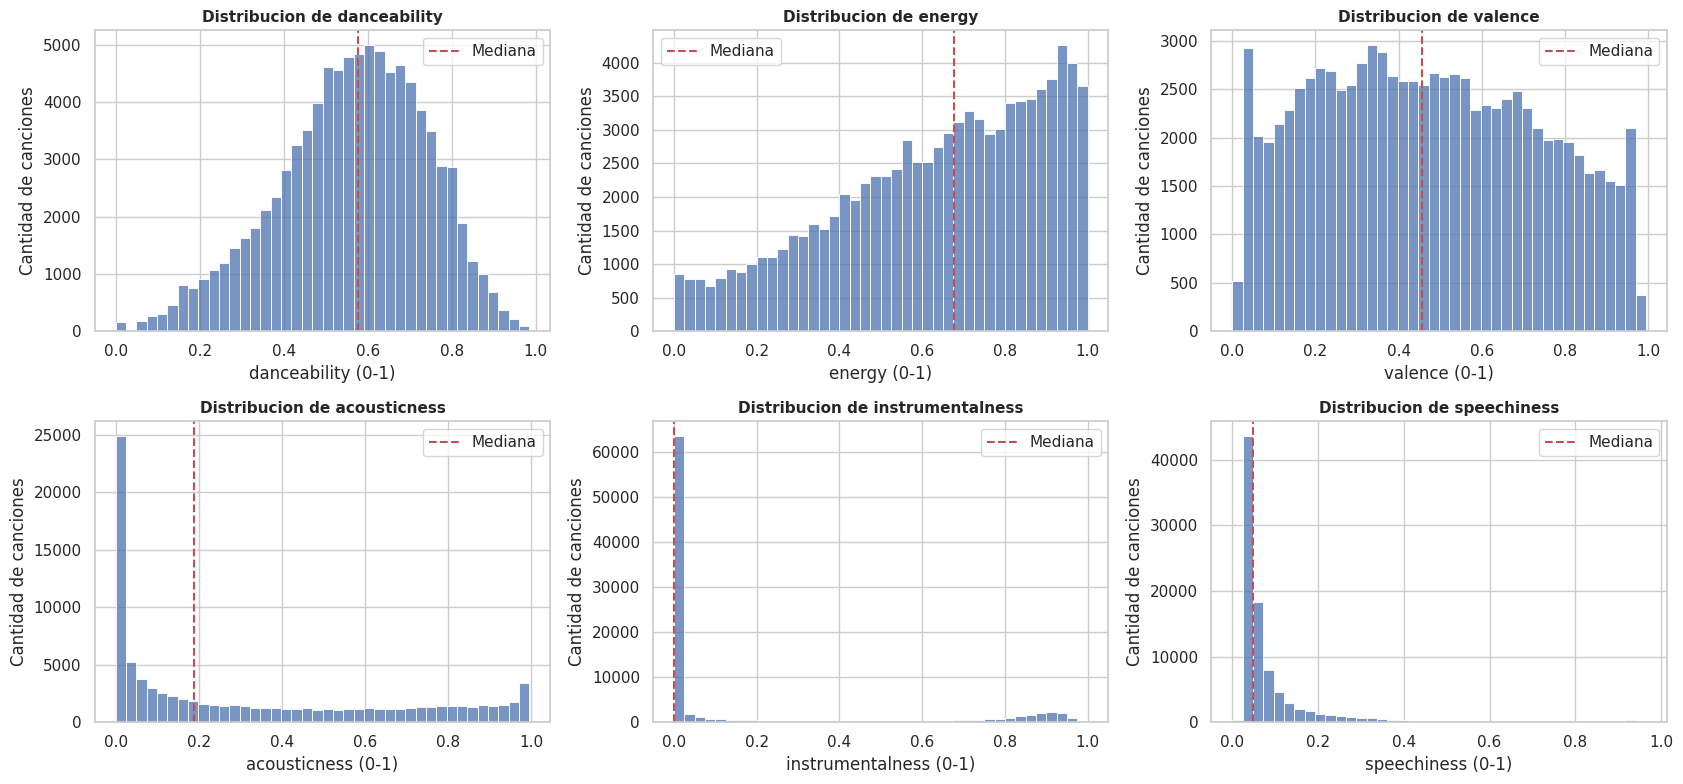

In [ ]:
# Primer bloque: variables en escala [0, 1]
bloque_1 = ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'speechiness']

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
axes = axes.flatten()
for i, col in enumerate(bloque_1):
    sns.histplot(canciones_unicas[col], bins=40, color=COLOR_AUDIO, ax=axes[i])
    axes[i].axvline(canciones_unicas[col].median(), color=COLOR_ALERTA, linestyle='--', label='Mediana')
    axes[i].set_title(f'Distribucion de {col}')
    axes[i].set_xlabel(f'{col} (0-1)')
    axes[i].set_ylabel('Cantidad de canciones')
    axes[i].legend()
plt.tight_layout()
plt.show()

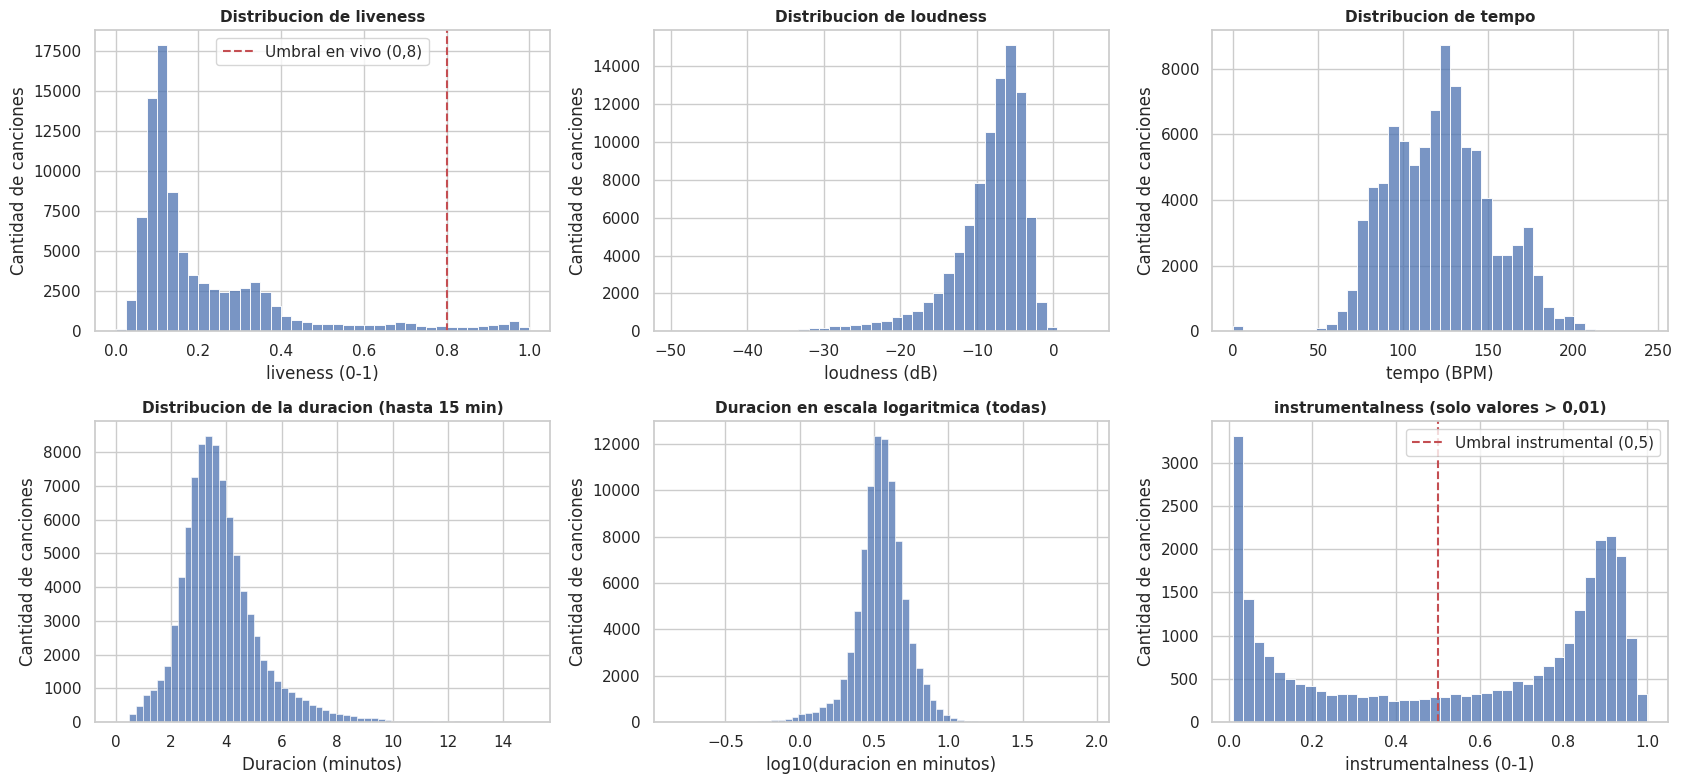

In [ ]:
# Segundo bloque: variables con unidades propias
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
axes = axes.flatten()

sns.histplot(canciones_unicas['liveness'], bins=40, color=COLOR_AUDIO, ax=axes[0])
axes[0].axvline(0.8, color=COLOR_ALERTA, linestyle='--', label='Umbral en vivo (0,8)')
axes[0].set_title('Distribucion de liveness')
axes[0].set_xlabel('liveness (0-1)')

sns.histplot(canciones_unicas['loudness'], bins=40, color=COLOR_AUDIO, ax=axes[1])
axes[1].set_title('Distribucion de loudness')
axes[1].set_xlabel('loudness (dB)')

sns.histplot(canciones_unicas['tempo'], bins=40, color=COLOR_AUDIO, ax=axes[2])
axes[2].set_title('Distribucion de tempo')
axes[2].set_xlabel('tempo (BPM)')

duracion_min = canciones_unicas['duration_ms'] / 60000
sns.histplot(duracion_min[duracion_min <= 15], bins=60, color=COLOR_AUDIO, ax=axes[3])
axes[3].set_title('Distribucion de la duracion (hasta 15 min)')
axes[3].set_xlabel('Duracion (minutos)')

sns.histplot(np.log10(canciones_unicas.loc[canciones_unicas['duration_ms'] > 0, 'duration_ms'] / 60000),
             bins=60, color=COLOR_AUDIO, ax=axes[4])
axes[4].set_title('Duracion en escala logaritmica (todas)')
axes[4].set_xlabel('log10(duracion en minutos)')

sns.histplot(canciones_unicas['instrumentalness'][canciones_unicas['instrumentalness'] > 0.01],
             bins=40, color=COLOR_AUDIO, ax=axes[5])
axes[5].axvline(0.5, color=COLOR_ALERTA, linestyle='--', label='Umbral instrumental (0,5)')
axes[5].set_title('instrumentalness (solo valores > 0,01)')
axes[5].set_xlabel('instrumentalness (0-1)')

for ax in axes:
    ax.set_ylabel('Cantidad de canciones')
axes[0].legend()
axes[5].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Asimetria por variable y proporcion de valores cercanos a cero
# El porcentaje de valores cercanos a 0 solo tiene sentido en las variables de escala [0, 1]
forma = pd.DataFrame({
    'asimetria': canciones_unicas[col_continuas].skew(),
    '% valores < 0.01': (canciones_unicas[col_proporcion] < 0.01).mean() * 100,
}).sort_values('asimetria', key=abs, ascending=False)
forma

,asimetria,% valores < 0.01
duration_ms,11.072,NaN
speechiness,4.546,0.175
liveness,2.062,0.004
loudness,-1.960,NaN
instrumentalness,1.564,68.225
acousticness,0.656,21.378
energy,-0.560,0.516
danceability,-0.398,0.175
tempo,0.183,NaN
valence,0.128,0.428


**Interpretacion.**

- **`danceability`, `energy` y `valence`** tienen distribuciones razonablemente simetricas (asimetria entre -0,56 y 0,13). No necesitan transformacion.
- **`acousticness`** tiene forma de U: el 21% de las canciones esta bajo 0,01 y hay otro grupo cerca de 1. Distingue producciones electronicas o electricas de acusticas.
- **`instrumentalness` es bimodal.** El 68% de las canciones esta bajo 0,01 (con voz). Entre las que superan ese valor, hay un grupo marcado entre 0,8 y 1 (instrumentales). Una transformacion no la vuelve simetrica; es mas natural resumirla en una variable binaria usando el umbral 0,5 de la documentacion (seccion 4.7).
- **`speechiness` (4,5) y `liveness` (2,1)** tienen colas derechas largas. La mayoria de las canciones tiene poca palabra hablada y fue grabada en estudio.
- **`loudness` (-2,0)** se concentra entre -10 y -4 dB, con una cola hacia volumenes muy bajos.
- **`tempo`** es simetrico (0,18) y muestra el grupo de valores en 0 identificado antes.
- **`duration_ms` (11,1)** es la variable mas asimetrica. La mayoria de las canciones dura entre 2 y 6 minutos, pero hay pistas de mas de una hora. En escala logaritmica la distribucion se vuelve casi simetrica, lo que indica que una transformacion logaritmica o de potencia es adecuada.

**Implicancia:** transformar `duration_ms`, `speechiness`, `liveness` y `loudness` (seccion 4.11) y resumir `instrumentalness` en una variable binaria (seccion 4.7).

## 3.3 Variables discretas y binarias

**Pregunta:** ¿estan balanceadas las categorias de `explicit`, `mode`, `key` y `time_signature`?

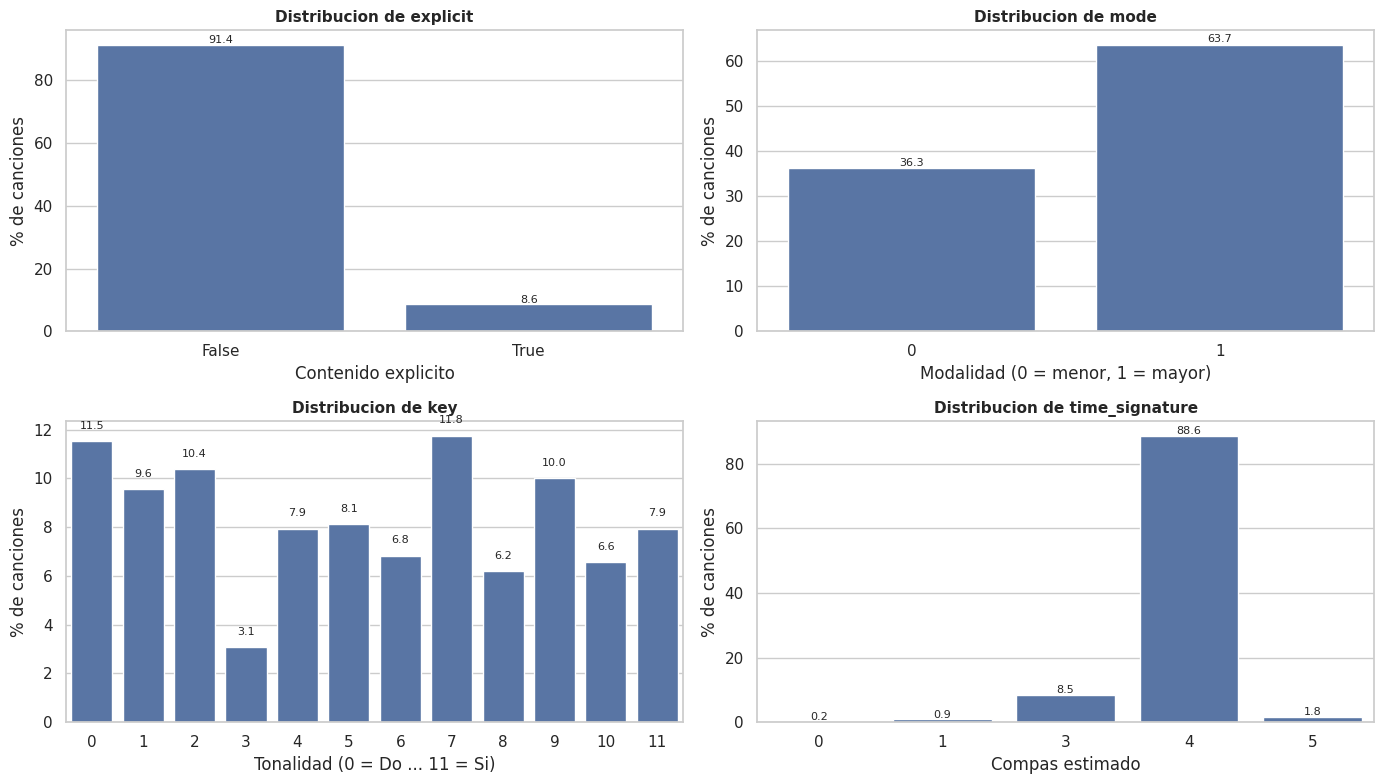

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
titulos = {
    'explicit': 'Contenido explicito',
    'mode': 'Modalidad (0 = menor, 1 = mayor)',
    'key': 'Tonalidad (0 = Do ... 11 = Si)',
    'time_signature': 'Compas estimado',
}
for i, col in enumerate(col_discretas):
    porcentajes = canciones_unicas[col].value_counts(normalize=True).sort_index() * 100
    sns.barplot(x=porcentajes.index.astype(str), y=porcentajes.values, color=COLOR_AUDIO, ax=axes[i])
    axes[i].set_title(f'Distribucion de {col}')
    axes[i].set_xlabel(titulos[col])
    axes[i].set_ylabel('% de canciones')
    # Etiqueta con el porcentaje sobre cada barra
    for j, valor in enumerate(porcentajes.values):
        axes[i].text(j, valor + 0.5, f'{valor:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

**Interpretacion.**

- **`explicit` esta muy desbalanceada:** solo el 8,6% de las canciones es explicita.
- **`mode`:** el 63,7% esta en tonalidad mayor.
- **`key`** se reparte de forma relativamente pareja entre los 12 tonos (entre 6% y 12%). La excepcion es Re# / Mi bemol (`key = 3`, 3,1%), una tonalidad menos usada en guitarra y piano.
- **`time_signature`** esta dominada por el compas 4/4 (88,6%). Los compases 3 (8,5%), 5 (1,8%), 1 (0,9%) y 0 (0,2%) son minoritarios. Con tan pocos casos, las categorias 0, 1 y 5 dificilmente permitirian estimar un efecto propio.

**Implicancia:** resumir `time_signature` en una variable binaria "compas 4/4 si / no" (seccion 4.7).

## 3.4 Generos musicales

**Pregunta:** ¿cuanto varia la popularidad entre generos y en cuantos generos aparece cada cancion?

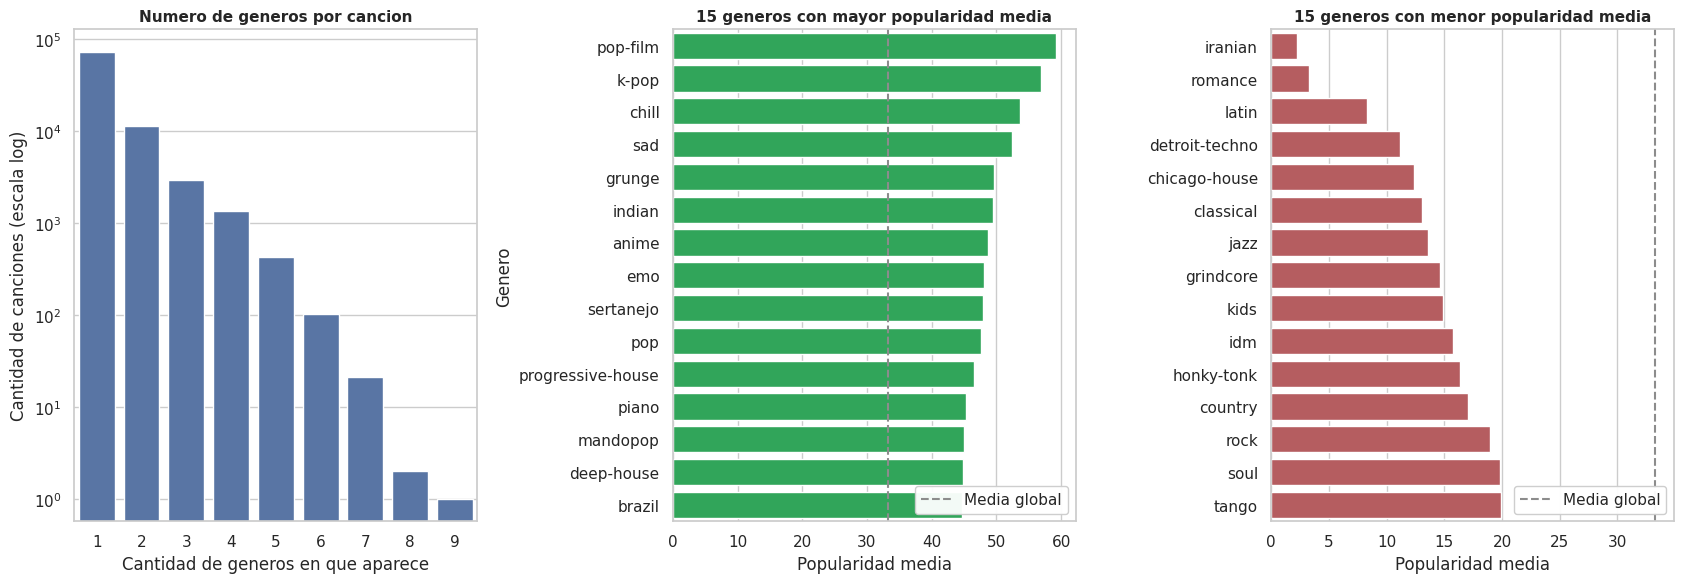

Rango de popularidad media entre generos: 2.2 - 59.3
Desviacion estandar de las medias por genero: 11.3


In [ ]:
# Popularidad media por genero (una fila por cancion y genero, tal como viene el archivo)
pop_genero = df.groupby('track_genre')['popularity'].mean().sort_values()

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

generos_por_cancion_eda = df.groupby('track_id')['track_genre'].nunique()
conteo_generos = generos_por_cancion_eda.value_counts().sort_index()
sns.barplot(x=conteo_generos.index.astype(str), y=conteo_generos.values, color=COLOR_AUDIO, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Numero de generos por cancion')
axes[0].set_xlabel('Cantidad de generos en que aparece')
axes[0].set_ylabel('Cantidad de canciones (escala log)')

top_15 = pop_genero.sort_values(ascending=False).head(15)
sns.barplot(x=top_15.values, y=top_15.index, color=COLOR_OBJETIVO, ax=axes[1])
axes[1].set_title('15 generos con mayor popularidad media')
axes[1].set_xlabel('Popularidad media')
axes[1].set_ylabel('Genero')

sns.barplot(x=pop_genero.head(15).values, y=pop_genero.head(15).index, color=COLOR_ALERTA, ax=axes[2])
axes[2].set_title('15 generos con menor popularidad media')
axes[2].set_xlabel('Popularidad media')
axes[2].set_ylabel('')

for ax in axes[1:]:
    ax.axvline(df['popularity'].mean(), color=COLOR_NEUTRO, linestyle='--', label='Media global')
    ax.legend(loc='lower right', framealpha=0.95)
plt.tight_layout()
plt.show()

print(f'Rango de popularidad media entre generos: {pop_genero.min():.1f} - {pop_genero.max():.1f}')
print(f'Desviacion estandar de las medias por genero: {pop_genero.std():.1f}')

**Interpretacion.**

- **Numero de generos por cancion.** La mayoria de las canciones aparece en un unico genero, pero mas de 16.000 aparecen en dos o mas (el eje esta en escala logaritmica).
- **La popularidad varia enormemente entre generos:** las medias van de 2,2 (`iranian`) a 59,3 (`pop-film`), con una desviacion de 11,3 puntos entre generos.
  - **Mas populares:** generos asociados a mercados de streaming masivo o a bandas sonoras (`pop-film`, `k-pop`, `chill`, `sad`, `grunge`, `indian`).
  - **Menos populares:** mercados regionales (`iranian`, `romance`, `latin`), nichos electronicos (`detroit-techno`, `chicago-house`) y catalogos antiguos (`classical`, `jazz`, `honky-tonk`, `country`, `soul`).
- **Coincidencia con los ceros.** Varios de los generos menos populares coinciden con los que concentraban popularidad 0 (seccion 3.1). Su media baja esta parcialmente inflada por las versiones duplicadas que se tratan en la seccion 4.5.

**Implicancia:** el genero sera probablemente el predictor mas fuerte. Con mas de 100 categorias, requiere una codificacion compacta (seccion 4.10), y su peso en el modelo debe interpretarse con cuidado, ya que la etiqueta de genero no es una clasificacion musical verificada (seccion 5.1).

## 3.5 Relacion de las variables numericas con la popularidad

**Pregunta:** ¿que caracteristicas de audio se asocian con la popularidad y de que forma (lineal o no lineal)?

Se calculan dos coeficientes: Pearson mide relacion lineal y Spearman relacion monotona basada en rangos, que es mas robusta frente a outliers y a variables muy asimetricas como `instrumentalness`.

In [ ]:
correlaciones_obj = pd.DataFrame({
    'pearson': canciones_unicas[col_continuas].corrwith(canciones_unicas['popularity']),
    'spearman': canciones_unicas[col_continuas].corrwith(canciones_unicas['popularity'], method='spearman'),
}).sort_values('spearman', key=abs, ascending=False)
correlaciones_obj

,pearson,spearman
instrumentalness,-0.127,-0.124
loudness,0.072,0.067
speechiness,-0.047,-0.067
danceability,0.064,0.055
energy,0.014,-0.016
duration_ms,-0.023,0.013
liveness,-0.014,-0.011
valence,-0.012,-0.011
acousticness,-0.039,0.010
tempo,0.007,0.008


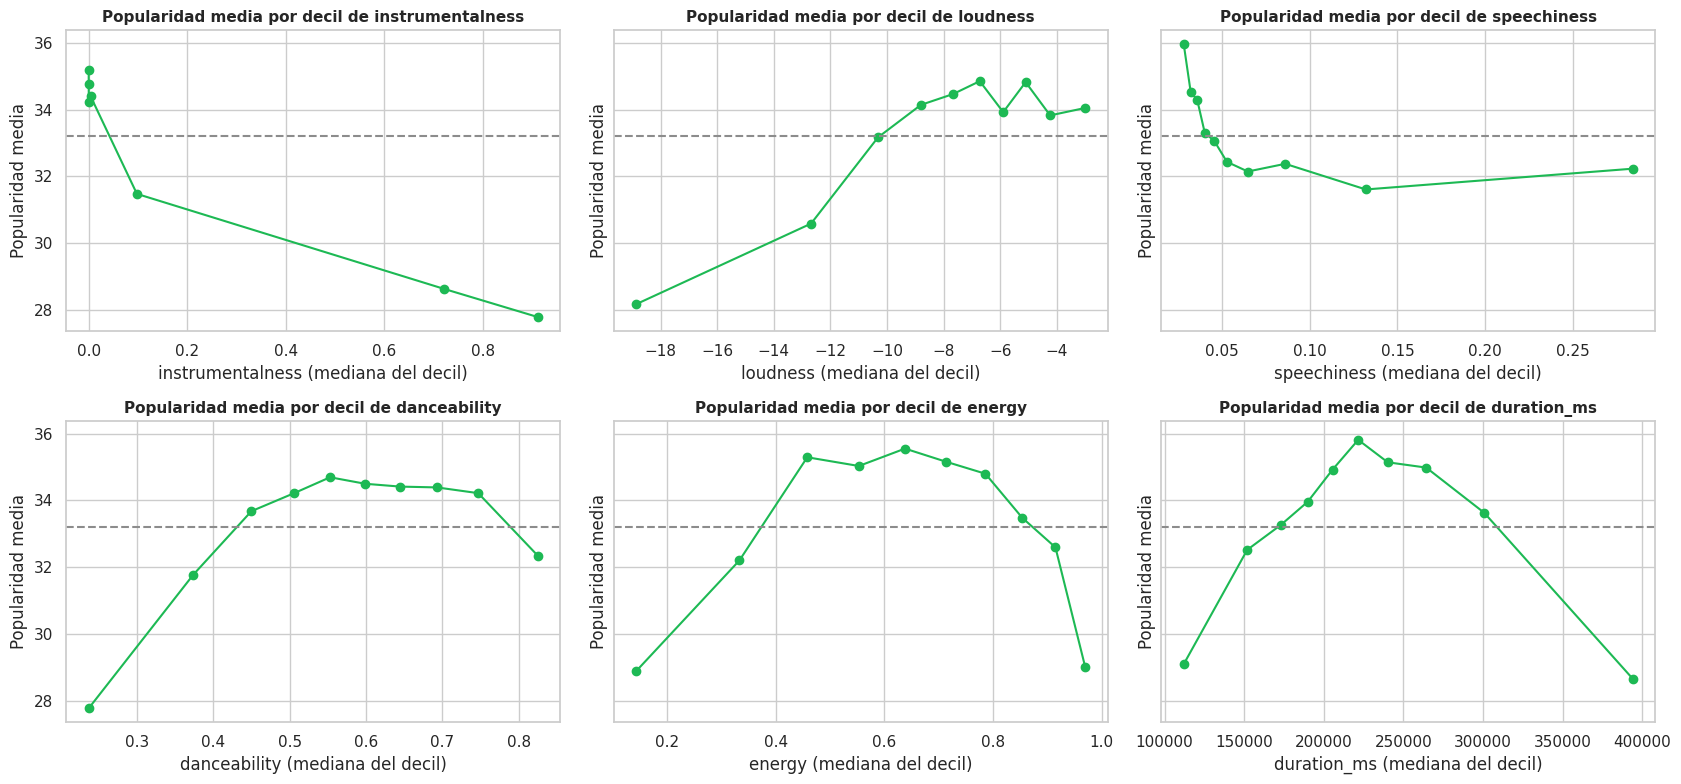

In [ ]:
# Popularidad media por decil de cada variable: permite ver relaciones no lineales
# que un coeficiente de correlacion no captura.
variables_top = correlaciones_obj.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharey=True)
axes = axes.flatten()
for i, col in enumerate(variables_top):
    # qcut divide la variable en 10 grupos de igual tamaño (algunos se fusionan si hay muchos empates)
    tramos = pd.qcut(canciones_unicas[col], q=10, duplicates='drop')
    resumen = canciones_unicas.groupby(tramos, observed=True).agg(
        valor=(col, 'median'), popularidad=('popularity', 'mean'))
    axes[i].plot(resumen['valor'], resumen['popularidad'], marker='o', color=COLOR_OBJETIVO)
    axes[i].axhline(canciones_unicas['popularity'].mean(), color=COLOR_NEUTRO, linestyle='--')
    axes[i].set_title(f'Popularidad media por decil de {col}')
    axes[i].set_xlabel(f'{col} (mediana del decil)')
    axes[i].set_ylabel('Popularidad media')
plt.tight_layout()
plt.show()

**Interpretacion.**

- **Correlaciones debiles.** Ninguna caracteristica de audio tiene una correlacion relevante con la popularidad. La mas alta es `instrumentalness` (Spearman -0,12), seguida de `loudness` (0,07) y `speechiness` (-0,07). Pearson y Spearman coinciden en signo y magnitud, por lo que los outliers no estan distorsionando el coeficiente.
- **Relaciones no lineales.** Los graficos por decil muestran patrones que un coeficiente lineal no captura:
  - `energy`, `danceability` y `duration_ms` tienen forma de **U invertida**. Las canciones con valores intermedios son las mas populares (alrededor de 35 puntos), mientras que las de ambos extremos caen a unos 28-29 puntos.
  - En `energy`, esto explica por que su correlacion es practicamente 0 (-0,02) aunque la diferencia entre deciles llega a 7 puntos.
  - `loudness` aumenta la popularidad hasta cerca de -9 dB y luego se estabiliza.
  - `instrumentalness` y `speechiness` tienen un efecto negativo concentrado en los valores altos.
- **Magnitud.** Aun asi, las diferencias entre deciles son de pocos puntos frente a una desviacion estandar de 20,6: **el audio por si solo explica una parte pequeña de la popularidad**.

**Implicancia:**

1. No se deben descartar variables por tener correlacion lineal baja.
2. Los modelos no lineales (arboles, *boosting*) son candidatos naturales para la etapa de modelado.
3. Las expectativas del KPI de R^2 deben ser moderadas (seccion 1.5).

## 3.6 Relacion de las variables categoricas con la popularidad

**Pregunta:** ¿que tanto explica cada variable categorica las diferencias de popularidad?

Para comparar variables con distinto numero de categorias se usa la **razon de correlacion n^2 (eta cuadrado)**: la proporcion de la varianza de la popularidad explicada por las diferencias entre las medias de cada categoria. Va de 0 (no explica nada) a 1 (explica todo).

In [ ]:
def eta_cuadrado(datos, categoria, objetivo='popularity'):
    # Varianza entre grupos dividida por la varianza total
    media_global = datos[objetivo].mean()
    grupos = datos.groupby(categoria)[objetivo].agg(['mean', 'size'])
    varianza_entre = (grupos['size'] * (grupos['mean'] - media_global) ** 2).sum()
    varianza_total = ((datos[objetivo] - media_global) ** 2).sum()
    return varianza_entre / varianza_total


eta_resultados = pd.Series({
    col: eta_cuadrado(canciones_unicas, col) for col in col_discretas + ['track_genre']
}, name='eta_cuadrado').sort_values(ascending=False)
eta_resultados

track_genre      0.326
time_signature   0.005
explicit         0.003
key              0.001
mode             0.000
Name: eta_cuadrado, dtype: float64

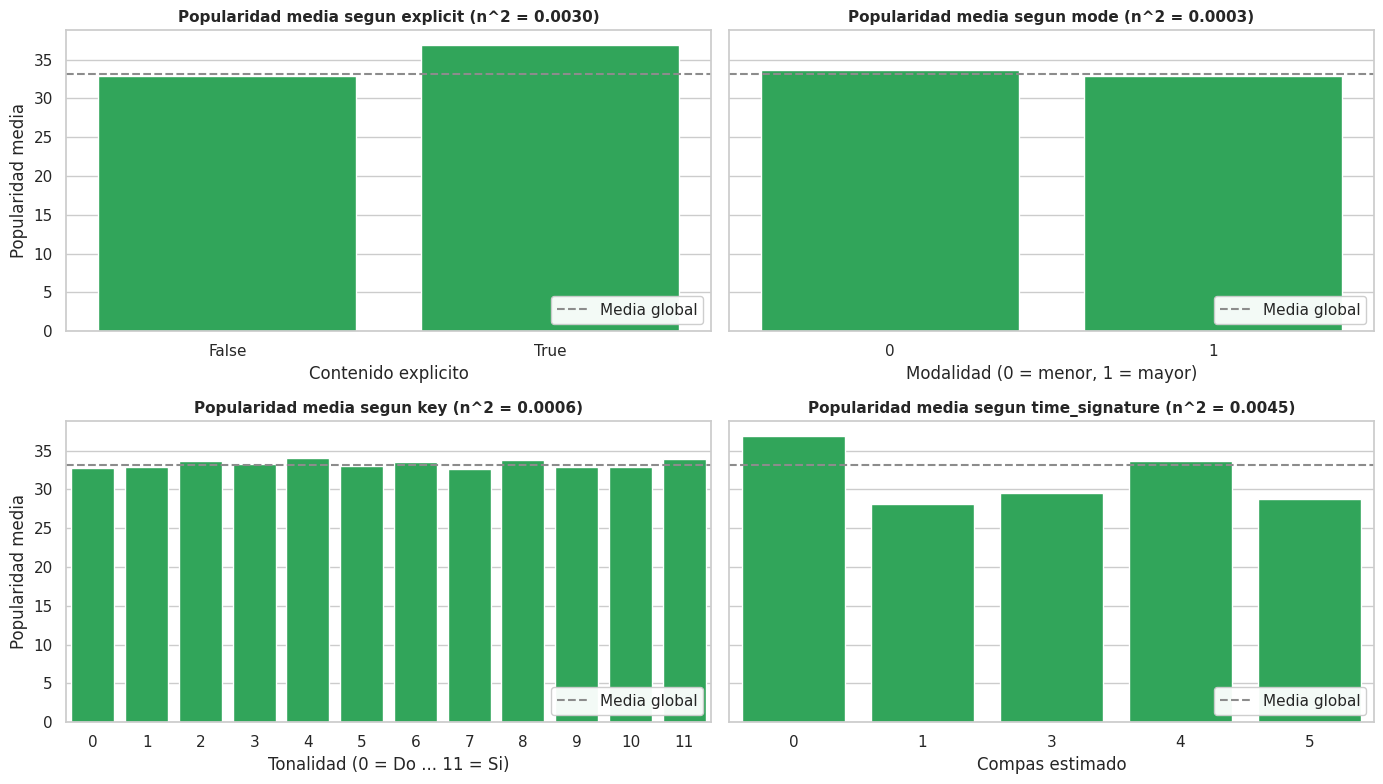

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes = axes.flatten()
for i, col in enumerate(col_discretas):
    medias = canciones_unicas.groupby(col)['popularity'].mean()
    sns.barplot(x=medias.index.astype(str), y=medias.values, color=COLOR_OBJETIVO, ax=axes[i])
    axes[i].axhline(canciones_unicas['popularity'].mean(), color=COLOR_NEUTRO, linestyle='--', label='Media global')
    axes[i].set_title(f'Popularidad media segun {col} (n^2 = {eta_resultados[col]:.4f})')
    axes[i].set_xlabel(titulos[col])
    axes[i].set_ylabel('Popularidad media')
    axes[i].legend(loc='lower right', framealpha=0.95)
plt.tight_layout()
plt.show()

`track_genre` no entra en la grilla anterior porque tiene 113 categorias (no 2 a 5 como las demas) y un grafico de barras por categoria seria ilegible. Como es la variable con mayor n^2, se muestra aparte: la popularidad media de cada genero, ordenada de menor a mayor.

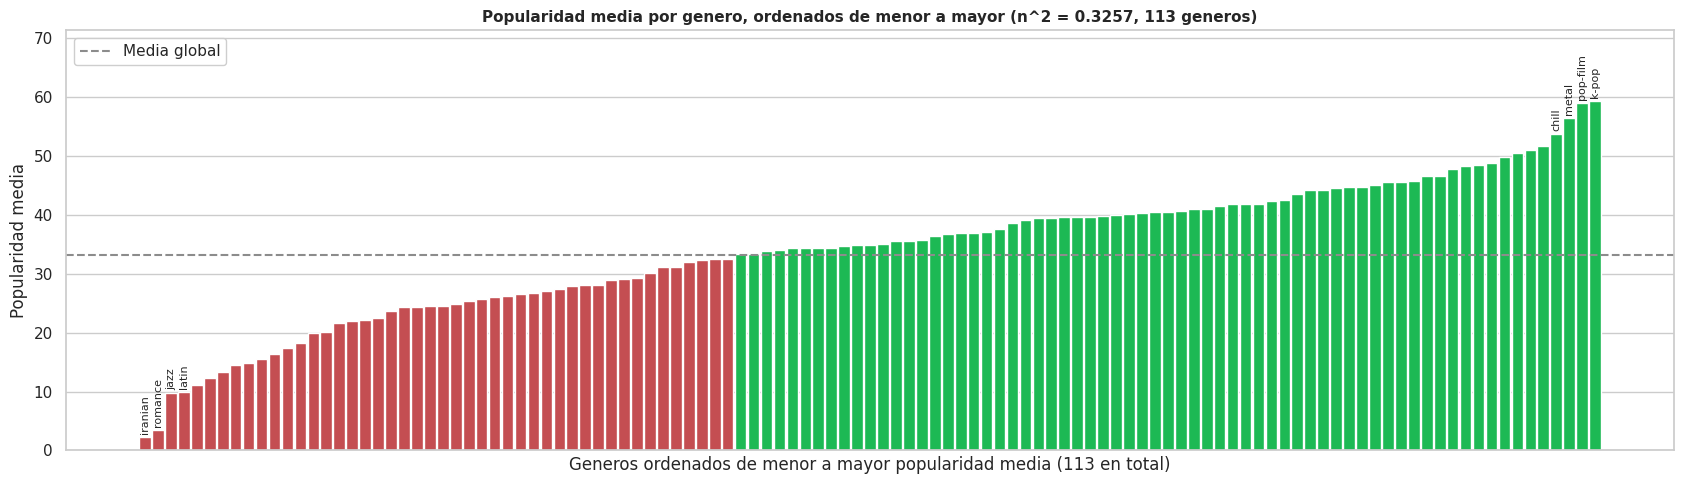

In [ ]:
medias_genero_orden = canciones_unicas.groupby('track_genre')['popularity'].mean().sort_values()
media_global = canciones_unicas['popularity'].mean()

fig, ax = plt.subplots(figsize=(17, 5))
colores_barras = [COLOR_ALERTA if v < media_global else COLOR_OBJETIVO for v in medias_genero_orden]
ax.bar(range(len(medias_genero_orden)), medias_genero_orden.values, color=colores_barras, width=0.9)
ax.axhline(media_global, color=COLOR_NEUTRO, linestyle='--', label='Media global')
ax.set_xticks([])
ax.set_ylim(0, medias_genero_orden.max() + 12)
ax.set_title(f'Popularidad media por genero, ordenados de menor a mayor (n^2 = {eta_resultados["track_genre"]:.4f}, '
             f'{medias_genero_orden.size} generos)')
ax.set_xlabel('Generos ordenados de menor a mayor popularidad media (113 en total)')
ax.set_ylabel('Popularidad media')
ax.legend(loc='upper left', framealpha=0.95)

# Se etiquetan solo los 4 generos mas extremos de cada lado, para no saturar el grafico
extremos = list(range(4)) + list(range(len(medias_genero_orden) - 4, len(medias_genero_orden)))
for posicion in extremos:
    ax.annotate(medias_genero_orden.index[posicion],
                (posicion, medias_genero_orden.values[posicion] + 0.5),
                rotation=90, fontsize=8, ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Interpretacion.**

- **`track_genre` domina.** Explica el 32,6% de la varianza de la popularidad (n^2 = 0,326).
- **Las demas variables categoricas explican muy poco:**
  - `time_signature` (0,005).
  - `explicit` (0,003): las canciones explicitas tienen 4 puntos mas de popularidad media (36,9 vs 32,9).
  - `key` (0,0006).
  - `mode` (0,0003): practicamente sin efecto.
- **`time_signature`:** los compases 1, 3 y 5 tienen entre 4 y 6 puntos menos que el 4/4. El valor 0 aparece alto (36,9), pero corresponde a solo 163 filas, casi todas con contenido no musical, y no es interpretable.
- **`track_genre` en detalle.** El grafico ordenado de los 113 generos muestra que la brecha no se debe a un par de casos aislados: hay un gradiente continuo desde `iranian` (2,2) hasta `pop-film` (59,3), con la mayoria de los generos repartidos entre 25 y 45 puntos. Esto confirma que el n^2 alto no es un artefacto de pocos generos extremos, sino una diferencia sistematica a lo largo de toda la variable.

**Implicancias:**

1. `key` no aporta informacion y su codificacion one-hot agregaria 11 columnas, por lo que **se elimina** (seccion 4.8).
2. `mode` tambien tiene un efecto marginal, pero **se conserva** porque es una sola columna binaria sin costo de dimensionalidad y podria interactuar con otras variables (por ejemplo, con el genero) en modelos no lineales.
3. `time_signature` se resume en la variable `compas_4_4`.

## 3.7 Correlacion entre predictores y multicolinealidad

**Pregunta:** ¿hay variables que miden practicamente lo mismo? Si dos predictores estan muy correlacionados, un modelo lineal reparte su efecto de forma inestable y los coeficientes pierden interpretabilidad.

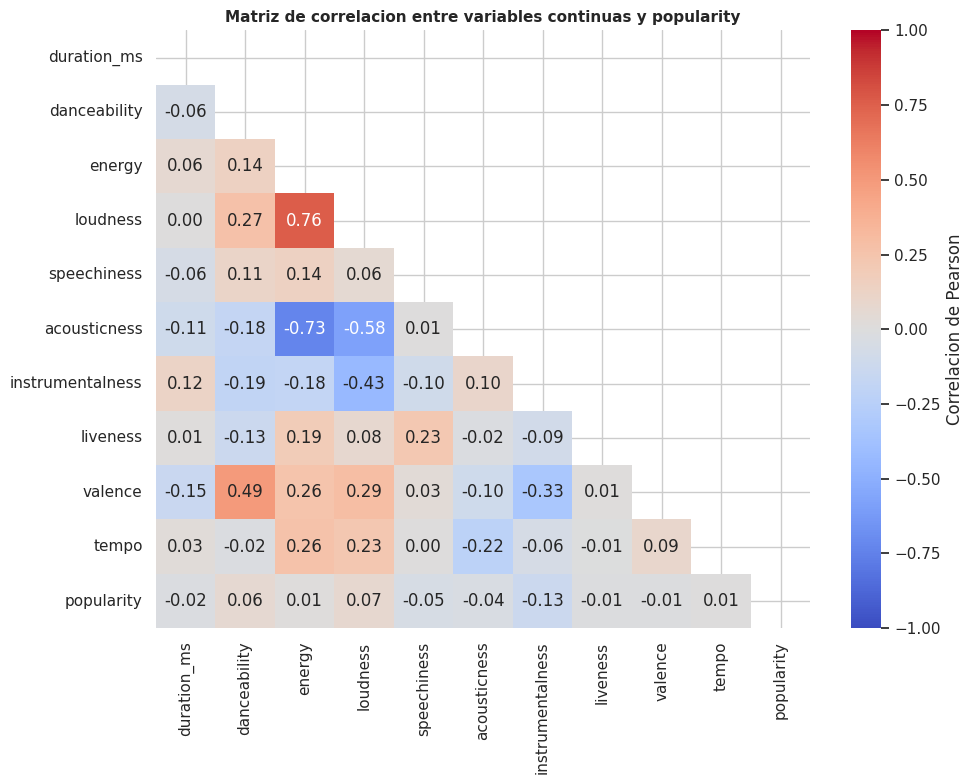

In [ ]:
matriz_corr = canciones_unicas[col_continuas + ['popularity']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mascara = np.triu(np.ones_like(matriz_corr, dtype=bool))  # oculta el triangulo superior repetido
sns.heatmap(matriz_corr, mask=mascara, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Correlacion de Pearson'})
ax.set_title('Matriz de correlacion entre variables continuas y popularity')
plt.tight_layout()
plt.show()

In [ ]:
# Pares de predictores con correlacion absoluta >= 0.5
corr_predictores = canciones_unicas[col_continuas].corr()
pares_corr = []
for i, var_1 in enumerate(col_continuas):
    for var_2 in col_continuas[i + 1:]:
        valor = corr_predictores.loc[var_1, var_2]
        if abs(valor) >= 0.5:
            pares_corr.append({'variable_1': var_1, 'variable_2': var_2, 'correlacion': valor})
pd.DataFrame(pares_corr).sort_values('correlacion', key=abs, ascending=False)

,variable_1,variable_2,correlacion
0,energy,loudness,0.759
1,energy,acousticness,-0.733
2,loudness,acousticness,-0.583


In [ ]:
def calcular_vif(datos):
    # VIF = 1 / (1 - R^2), donde R^2 se obtiene al predecir cada variable con todas las demas.
    # VIF > 5 suele considerarse multicolinealidad relevante y VIF > 10 severa.
    resultados = {}
    for col in datos.columns:
        otras = datos.drop(columns=col)
        r2 = LinearRegression().fit(otras, datos[col]).score(otras, datos[col])
        resultados[col] = 1 / (1 - r2)
    return pd.Series(resultados, name='VIF').sort_values(ascending=False)


vif_inicial = calcular_vif(canciones_unicas[col_continuas])
vif_inicial

energy             4.244
loudness           3.267
acousticness       2.413
valence            1.596
danceability       1.523
instrumentalness   1.467
liveness           1.157
speechiness        1.143
tempo              1.094
duration_ms        1.051
Name: VIF, dtype: float64

**Interpretacion.**

- **Pares con correlacion alta.** Solo tres pares superan |0,5|, todos en torno a la "intensidad" de la produccion:
  - `energy`-`loudness` (0,76).
  - `energy`-`acousticness` (-0,73).
  - `loudness`-`acousticness` (-0,58).

  La relacion es esperable: una cancion mas energica suele estar mas comprimida y ser menos acustica.
- **VIF.** Todos los valores estan bajo 5; el maximo es `energy` con 4,24.
- **Correlacion con el objetivo.** Ninguna variable continua supera |0,13| con `popularity`, lo que confirma lo visto en la seccion 3.5.

**Implicancia:** no hay multicolinealidad severa entre las variables originales. Se conservan las tres, porque cada una aporta un matiz distinto (intensidad percibida, volumen medido y tipo de instrumentacion). La verificacion se repite en la seccion 4.8, despues de crear variables nuevas.

## 3.8 Deteccion de outliers

**Pregunta:** ¿que variables tienen valores atipicos y esos valores son errores o variacion real del contenido musical?

Se usa el criterio del rango intercuartilico (IQR): un valor es atipico si esta bajo Q1 - 1,5*IQR o sobre Q3 + 1,5*IQR.

In [ ]:
def resumen_outliers_iqr(datos, columnas):
    filas = []
    for col in columnas:
        q1 = datos[col].quantile(0.25)
        q3 = datos[col].quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        cantidad = ((datos[col] < limite_inferior) | (datos[col] > limite_superior)).sum()
        filas.append({'variable': col, 'lim_inferior': limite_inferior, 'lim_superior': limite_superior,
                      'outliers': cantidad, '% outliers': cantidad / len(datos) * 100})
    return pd.DataFrame(filas).sort_values('outliers', ascending=False).set_index('variable')


tabla_outliers = resumen_outliers_iqr(canciones_unicas, col_continuas)
tabla_outliers

,lim_inferior,lim_superior,outliers,% outliers
variable,,,,
instrumentalness,-0.146,0.244,19613,21.855
speechiness,-0.039,0.161,10644,11.861
liveness,-0.173,0.550,6981,7.779
loudness,-18.143,2.713,5026,5.601
duration_ms,36160.500,401172.500,4226,4.709
tempo,38.044,201.297,514,0.573
danceability,0.087,1.055,474,0.528
energy,-0.137,1.447,0,0.000
acousticness,-0.895,1.537,0,0.000


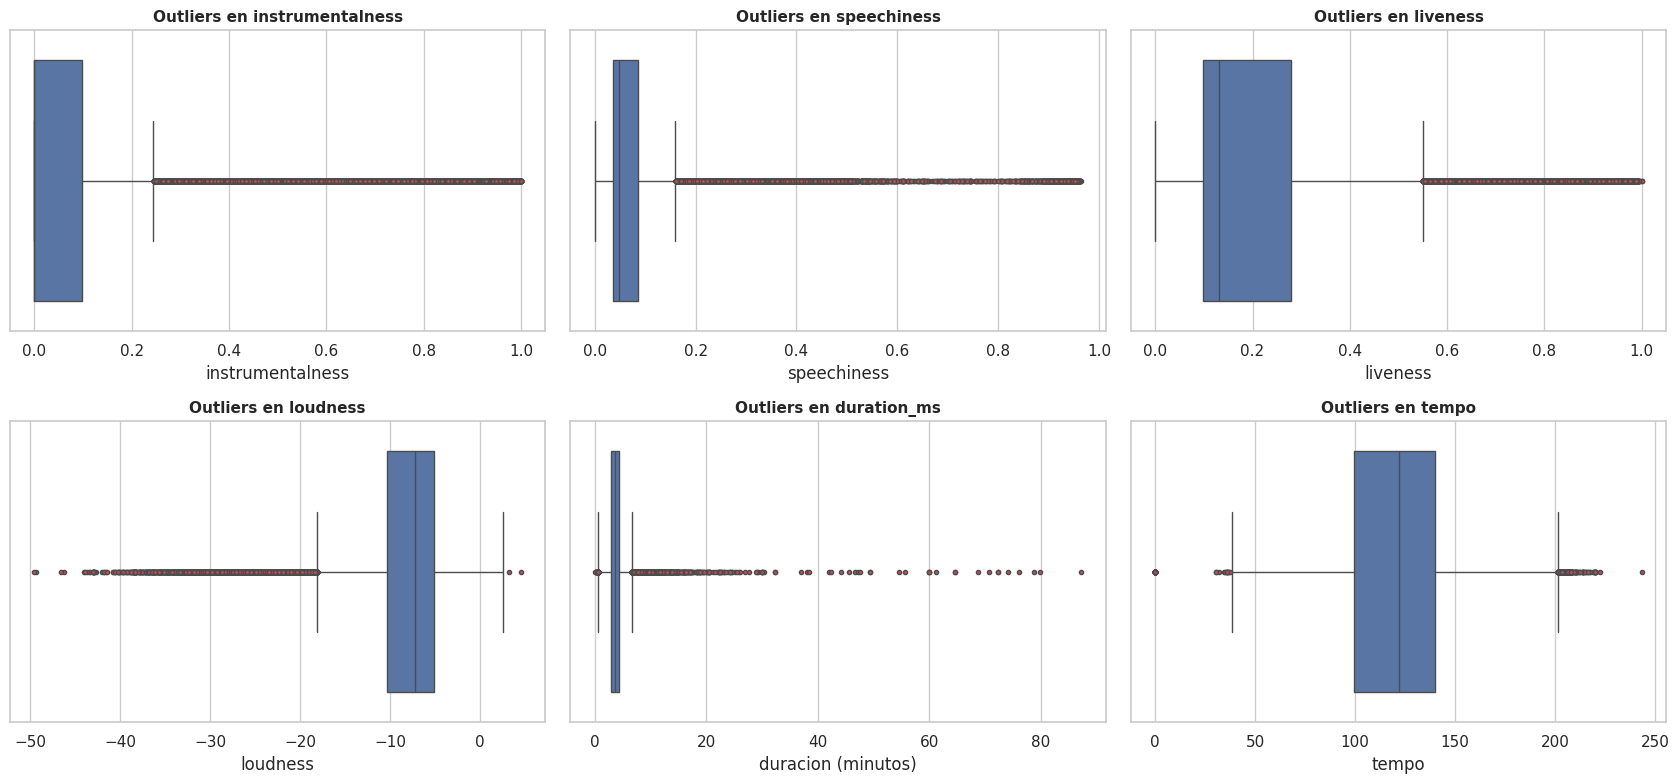

In [ ]:
variables_outliers = tabla_outliers[tabla_outliers['outliers'] > 0].index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
axes = axes.flatten()
for i, col in enumerate(variables_outliers):
    valores = canciones_unicas[col]
    etiqueta = col
    if col == 'duration_ms':
        valores = valores / 60000
        etiqueta = 'duracion (minutos)'
    sns.boxplot(x=valores, color=COLOR_AUDIO, flierprops={'markerfacecolor': COLOR_ALERTA, 'markersize': 3},
                ax=axes[i])
    axes[i].set_title(f'Outliers en {col}')
    axes[i].set_xlabel(etiqueta)
plt.tight_layout()
plt.show()

In [ ]:
# ¿Que contenido hay detras de los valores extremos?
print('Generos de las canciones de mas de 10 minutos:')
print(canciones_unicas.loc[canciones_unicas['duration_ms'] > 600000, 'track_genre'].value_counts().head(6))
print(f"Duracion maxima: {canciones_unicas['duration_ms'].max() / 60000:.1f} minutos")

print('\nGeneros con speechiness > 0.66 (contenido casi solo hablado):')
print(canciones_unicas.loc[canciones_unicas['speechiness'] > 0.66, 'track_genre'].value_counts().head(6))

print('\nGeneros con liveness > 0.8 (probable grabacion en vivo):')
print(canciones_unicas.loc[canciones_unicas['liveness'] > 0.8, 'track_genre'].value_counts().head(6))

print('\nGeneros con loudness < -30 dB:')
print(canciones_unicas.loc[canciones_unicas['loudness'] < -30, 'track_genre'].value_counts().head(6))

Generos de las canciones de mas de 10 minutos:
track_genre
detroit-techno    58
iranian           51
new-age           40
black-metal       35
classical         35
chicago-house     29
Name: count, dtype: int64
Duracion maxima: 87.3 minutos

Generos con speechiness > 0.66 (contenido casi solo hablado):
track_genre
comedy        764
kids           11
children       10
show-tunes     10
funk            9
jazz            5
Name: count, dtype: int64

Generos con liveness > 0.8 (probable grabacion en vivo):
track_genre
comedy       375
pagode       279
sleep        177
sertanejo    174
samba        125
mpb          106
Name: count, dtype: int64

Generos con loudness < -30 dB:
track_genre
sleep        277
ambient       92
classical     85
piano         72
iranian       24
new-age       23
Name: count, dtype: int64


**Interpretacion.** El criterio IQR marca muchos valores, pero su significado cambia segun la variable:

- **`instrumentalness` (21,9%).** No son outliers en sentido estricto: como Q1 y la mediana son 0, el IQR es tan estrecho que cualquier cancion instrumental queda fuera del rango. Es un efecto de la distribucion bimodal, no de valores anomalos.
- **`speechiness` (11,9%).** Los valores sobre 0,66 (contenido casi solo hablado) pertenecen mayoritariamente a `comedy` (764 canciones). Es un tipo de contenido real.
- **`liveness` (7,8%).** Las grabaciones en vivo se concentran en `comedy` y en generos brasileños (`pagode`, `sertanejo`, `samba`, `mpb`), donde las grabaciones en vivo son habituales. `sleep` tambien aparece, probablemente por el ruido ambiental.
- **`loudness` (5,6%).** Los volumenes bajo -30 dB provienen de `sleep`, `ambient`, `classical` y `piano`: musica grabada a bajo volumen de forma intencional.
- **`duration_ms` (4,7%).** Las pistas de mas de 10 minutos son sesiones de `detroit-techno`, `chicago-house`, `black-metal`, `new-age`, `classical` y musica irani; el maximo es de 87 minutos.
- **`tempo` y `danceability` (0,5% cada una).** Tienen pocos casos extremos.

**Implicancia:** los valores atipicos son **variacion legitima entre tipos de contenido**, no errores de captura. Eliminarlos quitaria generos completos del dataset. La decision detallada esta en la seccion 4.6.

## 3.9 Sintesis del EDA y decisiones derivadas

| Hallazgo | Evidencia | Decision de preparacion |
|---|---|---|
| Canciones repetidas por genero y etiquetas solapadas | 24.259 filas extra; `songwriter` identico a `singer-songwriter` | Unificar etiquetas y dejar una fila por cancion (4.3) |
| Popularidad 0 artificial en versiones duplicadas | 30% de los ceros tiene una version popular | Eliminar esas versiones (4.5) |
| Contenido no musical con tempo 0 | 157 filas, 88% de `sleep` | Eliminar (4.4) |
| Audio con relacion debil y no lineal con la popularidad | Correlaciones <= 0,13; forma de U invertida en `energy`, `danceability` y duracion | Conservar todas las variables de audio; preferir modelos no lineales |
| El genero es el predictor dominante | n^2 = 0,326 | Target encoding sin fuga de datos (4.10) |
| `key` y `mode` casi sin efecto | n^2 < 0,001 | Eliminar `key`; conservar `mode` por su bajo costo (4.8) |
| `instrumentalness` bimodal | 68% bajo 0,01 | Resumir en `es_instrumental` (4.7) |
| `time_signature` dominada por 4/4 | 88,6% | Resumir en `compas_4_4` (4.7) |
| Asimetria fuerte en duracion, habla, vivo y volumen | Asimetria entre 2 y 11 en valor absoluto | Transformacion Yeo-Johnson (4.11) |
| Escalas muy distintas | ms, dB, BPM y proporciones | `StandardScaler` (4.11) |
| Outliers legitimos | Asociados a generos concretos | Conservar (4.6) |
| Multicolinealidad moderada | VIF maximo 4,2 | Sin eliminaciones; volver a verificar (4.8) |

---
# 4. Preprocesamiento de datos

El orden de los pasos responde a una regla: **todo lo que no aprende parametros de los datos se aplica antes de dividir en entrenamiento y prueba; todo lo que si los aprende (codificacion por objetivo, transformaciones y escalado) se ajusta solo con entrenamiento.** Asi se evita la fuga de datos.

| Paso | Accion | ¿Aprende de los datos? |
|---|---|---|
| 4.1 - 4.2 | Eliminar artefactos, nulos y duplicados exactos | No |
| 4.3 | Unificar etiquetas de genero y dejar una fila por cancion | No |
| 4.4 | Tratar valores invalidos | No |
| 4.5 | Eliminar versiones con popularidad 0 artificial | No |
| 4.6 | Decision sobre outliers | No |
| 4.7 | Ingenieria de caracteristicas | No |
| 4.8 | Seleccion de variables y multicolinealidad | No |
| 4.9 | Division train / test agrupada | - |
| 4.10 | Codificacion de variables categoricas | Si (solo train) |
| 4.11 | Transformacion y escalado | Si (solo train) |
| 4.12 | Verificacion final y exportacion | - |

## 4.1 Copia de trabajo y eliminacion del indice exportado

In [ ]:
# Se trabaja sobre una copia para conservar el archivo original intacto
df_prep = df.copy()

# 'Unnamed: 0' es el numero de fila guardado al exportar el CSV (verificado en 2.8.2)
df_prep = df_prep.drop(columns='Unnamed: 0')
print(f'Dimensiones: {df_prep.shape}')

Dimensiones: (114000, 20)


## 4.2 Valores nulos y duplicados exactos

**Nulos.** Hay una sola fila con nulos y ademas tiene `duration_ms = 0` (seccion 2.8.1). No se imputa: los campos faltantes son identificadores de texto (artista, album, titulo) que no se pueden estimar, y la duracion 0 confirma que es un registro defectuoso. Eliminar 1 fila de 114.000 no afecta el analisis.

**Duplicados exactos.** Son filas identicas en todas las columnas (misma cancion, mismo genero, misma popularidad). No aportan informacion nueva y solo duplican el peso de esas canciones.

In [ ]:
filas_inicio = len(df_prep)

df_prep = df_prep.dropna(subset=['artists', 'album_name', 'track_name'])
print(f'Filas eliminadas por nulos       : {filas_inicio - len(df_prep)}')

filas_antes = len(df_prep)
df_prep = df_prep.drop_duplicates()
print(f'Filas eliminadas por duplicados  : {filas_antes - len(df_prep)}')
print(f'Filas restantes                  : {len(df_prep):,}')

Filas eliminadas por nulos       : 1
Filas eliminadas por duplicados  : 450
Filas restantes                  : 113,549


## 4.3 Una fila por cancion

Como se vio en la seccion 2.8.3, una misma cancion aparece varias veces cuando fue recuperada desde varios generos. Las copias son identicas en todas las caracteristicas de audio y solo cambian en el genero y, en pocos casos, en la popularidad. Mantenerlas genera tres problemas:

1. **Fuga de datos:** la misma cancion podria quedar en entrenamiento y en prueba, inflando artificialmente las metricas.
2. **Sobrerrepresentacion:** una cancion con 5 copias pesaria 5 veces mas en el entrenamiento.
3. **Objetivo contradictorio:** el mismo vector de audio con popularidades distintas.

**Decisiones:**

- **Unificar etiquetas equivalentes.** `songwriter` y `singer-songwriter` contienen exactamente las mismas canciones (seccion 2.8.3), por lo que se tratan como un solo genero.
- **Popularidad = promedio entre copias.** Las diferencias son minimas (normalmente 1 punto) y provienen de consultas hechas en momentos distintos; el promedio no favorece a ninguna de ellas.
- **Nueva variable `n_generos`.** Registra en cuantos generos aparece la cancion, para no perder la informacion de las etiquetas descartadas.
- **Genero conservado elegido al azar (semilla fija).** El archivo esta ordenado alfabeticamente por genero; conservar la primera aparicion favoreceria sistematicamente a los generos que empiezan con las primeras letras. Antes de aplicarlo se compara el efecto de ambas estrategias.

In [ ]:
# Unificar la etiqueta duplicada de genero
df_prep['track_genre'] = df_prep['track_genre'].replace('songwriter', 'singer-songwriter')

# Tras unificar, una misma cancion puede quedar dos veces con el mismo genero: se eliminan esas filas
filas_antes = len(df_prep)
df_prep = df_prep.drop_duplicates(subset=['track_id', 'track_genre'])
print(f'Filas eliminadas al unificar songwriter: {filas_antes - len(df_prep):,}')

# Informacion que se calcula ANTES de quedarse con una fila por cancion
popularidad_media = df_prep.groupby('track_id')['popularity'].mean().round().astype(int)
n_generos = df_prep.groupby('track_id')['track_genre'].nunique()

Filas eliminadas al unificar songwriter: 1,000


In [ ]:
# Comparacion de estrategias: ¿cuantas canciones conserva cada genero?
estrategia_primera = df_prep.drop_duplicates(subset='track_id', keep='first')
estrategia_azar = df_prep.sample(frac=1, random_state=SEMILLA).drop_duplicates(subset='track_id', keep='first')

comparacion_estrategias = pd.DataFrame({
    'primera aparicion': estrategia_primera['track_genre'].value_counts().describe(),
    'seleccion al azar': estrategia_azar['track_genre'].value_counts().describe(),
}).loc[['count', 'mean', 'std', 'min', 'max']]
print(comparacion_estrategias.round(1))
print('\nGeneros mas reducidos con la estrategia "primera aparicion":')
print(estrategia_primera['track_genre'].value_counts().tail(5))

       primera aparicion  seleccion al azar
count            113.000            113.000
mean             794.200            794.200
std              226.200            171.600
min               74.000            371.000
max             1000.000           1000.000

Generos mas reducidos con la estrategia "primera aparicion":
track_genre
metal        232
punk         226
house        210
indie        134
reggaeton     74
Name: count, dtype: int64


In [ ]:
# Se aplica la seleccion al azar y se reordena por el indice original
df_prep = estrategia_azar.sort_index().copy()

# Se reemplaza la popularidad por el promedio entre copias y se agrega n_generos
df_prep['popularity'] = df_prep['track_id'].map(popularidad_media)
df_prep['n_generos'] = df_prep['track_id'].map(n_generos)

print(f"Filas: {len(df_prep):,} | track_id unicos: {df_prep['track_id'].nunique():,}")
print(f"Generos restantes: {df_prep['track_genre'].nunique()}")

Filas: 89,740 | track_id unicos: 89,740
Generos restantes: 113


**Interpretacion.**

- **Unificacion de generos.** Al unificar `songwriter` desaparecen 1.000 filas y el dataset queda con 113 generos.
- **Comparacion de estrategias.** Ambas conservan el mismo numero de canciones, pero distribuyen la perdida de forma muy distinta:
  - **Primera aparicion:** `reggaeton` quedaria con solo 74 canciones e `indie` con 134, porque sus canciones ya habian sido asignadas a generos que aparecen antes en orden alfabetico (`latino`, `alternative`...).
  - **Seleccion al azar:** el genero mas reducido conserva 371 canciones y la desviacion entre generos baja de 226 a 172.
- **Resultado.** Queda **una fila por cancion (89.740)**. La popularidad corresponde al promedio entre copias y `n_generos` registra en cuantos generos aparecia cada cancion.

## 4.4 Valores invalidos

| Caso | Decision | Justificacion |
|---|---|---|
| `tempo = 0` | Eliminar filas | Casi todas pertenecen a `sleep` (ruido blanco, sonidos ambientales) y tienen ademas `time_signature = 0`: el algoritmo de Spotify no pudo analizar el ritmo porque no hay musica en sentido estricto. Son contenido fuera del alcance del problema (canciones) y sus caracteristicas de audio no son confiables. |
| `time_signature = 0` restantes | Imputar con la moda (4) | Son muy pocas filas; la moda concentra casi 90% de las canciones, por lo que es el valor mas probable y su efecto en la distribucion es despreciable. |
| `time_signature = 1` | Conservar | Aunque esta fuera del rango documentado, se concentra en generos sin metrica regular (comedia, sleep, clasica, ambient). Se interpreta como "compas irregular" y se integra en la variable binaria de la seccion 4.7. |
| `loudness > 0 dB` | Conservar | Son valores levemente positivos (maximo cercano a 4,5 dB), producto de masterizaciones muy comprimidas. Son fisicamente posibles y no son errores. |
| `speechiness > 0,66` | Eliminar filas | Segun la documentacion de Spotify, este umbral marca contenido hecho casi enteramente de palabra hablada (podcast, audiolibro, comedia hablada), no musica. El 87% de los casos es el genero `comedy`. No se elimina el genero completo porque una parte de sus canciones (parodias musicales) si tiene estructura de cancion y queda bajo el umbral. |

In [ ]:
filas_antes = len(df_prep)
df_prep = df_prep[df_prep['tempo'] > 0]
print(f'Filas eliminadas por tempo = 0 : {filas_antes - len(df_prep)}')

moda_compas = df_prep['time_signature'].mode()[0]
compas_cero = (df_prep['time_signature'] == 0).sum()
df_prep['time_signature'] = df_prep['time_signature'].replace(0, moda_compas)
print(f'time_signature = 0 imputados con la moda ({moda_compas}): {compas_cero}')

filas_antes = len(df_prep)
df_prep = df_prep[df_prep['speechiness'] <= 0.66]
print(f'Filas eliminadas por contenido casi enteramente hablado (speechiness > 0.66): '
      f'{filas_antes - len(df_prep)}')
print(f'Filas restantes: {len(df_prep):,}')

Filas eliminadas por tempo = 0 : 157
time_signature = 0 imputados con la moda (4): 5
Filas eliminadas por contenido casi enteramente hablado (speechiness > 0.66): 868
Filas restantes: 88,715


## 4.5 Versiones con popularidad 0 artificial

La seccion 3.1.1 mostro que una parte de las canciones con popularidad 0 tiene otra version (mismo artista y titulo) con popularidad positiva. En esos casos el 0 no refleja falta de interes de los oyentes: Spotify concentra las reproducciones en una de las versiones y la otra queda en 0. Entrenar con ellas enseñaria al modelo que un mismo perfil musical puede valer 0 y 60 a la vez, sin que ninguna variable explique la diferencia.

- **Se eliminan** las versiones con popularidad 0 que tienen una version popular.
- **Se conservan** las demas canciones con popularidad 0: no hay evidencia de que sean errores y representan canciones de muy bajo alcance, que el modelo tambien debe aprender a reconocer.

In [ ]:
# Canciones (artista + titulo) que tienen al menos una version con popularidad positiva
versiones_populares = df_prep.loc[df_prep['popularity'] > 0, ['artists', 'track_name']].drop_duplicates()
versiones_populares['tiene_version_popular'] = True

df_prep = df_prep.merge(versiones_populares, on=['artists', 'track_name'], how='left')
df_prep['tiene_version_popular'] = df_prep['tiene_version_popular'].fillna(False).astype(bool)

cero_artificial = (df_prep['popularity'] == 0) & df_prep['tiene_version_popular']
print(f'Versiones con popularidad 0 artificial eliminadas: {cero_artificial.sum():,}')

df_prep = df_prep[~cero_artificial].drop(columns='tiene_version_popular').reset_index(drop=True)
print(f"Canciones con popularidad 0 que se conservan     : {(df_prep['popularity'] == 0).sum():,}")
print(f'Filas restantes                                  : {len(df_prep):,}')

Versiones con popularidad 0 artificial eliminadas: 2,856
Canciones con popularidad 0 que se conservan     : 6,541
Filas restantes                                  : 85,859


## 4.6 Decision sobre outliers

El analisis de la seccion 3.8 mostro que los valores atipicos corresponden a **tipos de contenido reales** y no a errores de captura. Por eso no se eliminan filas por el criterio IQR; en su lugar, cada caso se trata con la herramienta que corresponde a su naturaleza:

| Variable | Que son los outliers | Tratamiento |
|---|---|---|
| `duration_ms` | Obras clasicas, sets electronicos y pistas ambientales largas | Se conservan; transformacion logaritmica / Yeo-Johnson para reducir la cola (4.11) |
| `speechiness` | Comedia, contenido hablado y rap | Se conservan; transformacion Yeo-Johnson (4.11) |
| `liveness` | Grabaciones en vivo (comedia, pagode, sertanejo, samba) | Se conservan; transformacion Yeo-Johnson (4.11) |
| `instrumentalness` | Distribucion bimodal: el IQR marca como outlier a todas las canciones instrumentales | Se conservan; se resume en una variable binaria `es_instrumental` (4.7) |
| `loudness` | Musica ambiental, clasica y de relajacion grabada a bajo volumen | Se conservan; escalado estandar (4.11) |
| `tempo`, `danceability` | Pocos casos en los extremos, coherentes con estilos musicales | Se conservan sin tratamiento especial |

Eliminar estas filas quitaria del modelo generos completos (clasica, comedia, ambient) y crearia un sesgo de representacion; recortar sus valores (*capping*) destruiria la informacion que distingue a esos generos.

In [ ]:
# Evidencia: porcentaje de outliers IQR que se concentra en los 5 generos mas frecuentes de cada variable
for col in ['duration_ms', 'speechiness', 'liveness', 'loudness']:
    q1 = df_prep[col].quantile(0.25)
    q3 = df_prep[col].quantile(0.75)
    iqr = q3 - q1
    es_outlier = (df_prep[col] < q1 - 1.5 * iqr) | (df_prep[col] > q3 + 1.5 * iqr)
    generos_outlier = df_prep.loc[es_outlier, 'track_genre'].value_counts(normalize=True)
    print(f'{col:12s}: {es_outlier.sum():>5} outliers | top 5 generos concentran '
          f'{generos_outlier.head(5).sum() * 100:.0f}% -> {", ".join(generos_outlier.head(5).index)}')

duration_ms :  4038 outliers | top 5 generos concentran 33% -> detroit-techno, chicago-house, minimal-techno, iranian, trance
speechiness :  9809 outliers | top 5 generos concentran 19% -> j-dance, dancehall, kids, hardcore, grindcore


liveness    :  6365 outliers | top 5 generos concentran 23% -> pagode, sertanejo, samba, sleep, mpb
loudness    :  4819 outliers | top 5 generos concentran 52% -> sleep, new-age, classical, ambient, piano


**Interpretacion.** En las cuatro variables, los outliers se concentran en pocos generos; en `loudness`, los 5 generos principales acumulan el 51% de los casos (`sleep`, `new-age`, `classical`, `ambient`, `piano`). Esto confirma que el valor extremo es una caracteristica del estilo musical y no un error aleatorio. Un modelo que no los vea seria incapaz de estimar la popularidad de esos generos.

## 4.7 Ingenieria de caracteristicas

Cada variable nueva resume informacion que ya existe pero que no esta en una forma util para el modelo.

| Variable nueva | Como se calcula | Que aporta |
|---|---|---|
| `duracion_min` | `duration_ms / 60000` | Misma informacion en una unidad interpretable; reemplaza a `duration_ms` |
| `n_artistas` | Numero de artistas separados por `;` | Las colaboraciones combinan audiencias de varios artistas |
| `es_instrumental` | `instrumentalness > 0,5` (umbral de la documentacion de Spotify) | Resume una variable bimodal en su distincion relevante: con voz o sin voz |
| `compas_4_4` | 1 si `time_signature == 4`, 0 en otro caso | El 89% de las canciones esta en 4/4; las demas categorias tienen muy pocos casos para estimarse por separado |
| `n_generos` | Creada en 4.3 | Canciones que cruzan varios generos llegan a audiencias mas amplias |
| `explicit` | Conversion de booleano a entero 0/1 | Formato numerico requerido por los modelos |

In [ ]:
df_prep['duracion_min'] = df_prep['duration_ms'] / 60000
df_prep['n_artistas'] = df_prep['artists'].str.count(';') + 1
df_prep['es_instrumental'] = (df_prep['instrumentalness'] > 0.5).astype(int)
df_prep['compas_4_4'] = (df_prep['time_signature'] == 4).astype(int)
df_prep['explicit'] = df_prep['explicit'].astype(int)

nuevas = ['duracion_min', 'n_artistas', 'n_generos', 'es_instrumental', 'compas_4_4']
df_prep[nuevas].describe().T[['mean', 'std', 'min', '50%', 'max']]

,mean,std,min,50%,max
duracion_min,3.838,1.878,0.263,3.575,87.288
n_artistas,1.376,0.873,1.000,1.000,38.000
n_generos,1.234,0.607,1.000,1.000,8.000
es_instrumental,0.192,0.394,0.000,0.000,1.000
compas_4_4,0.891,0.311,0.000,1.000,1.000


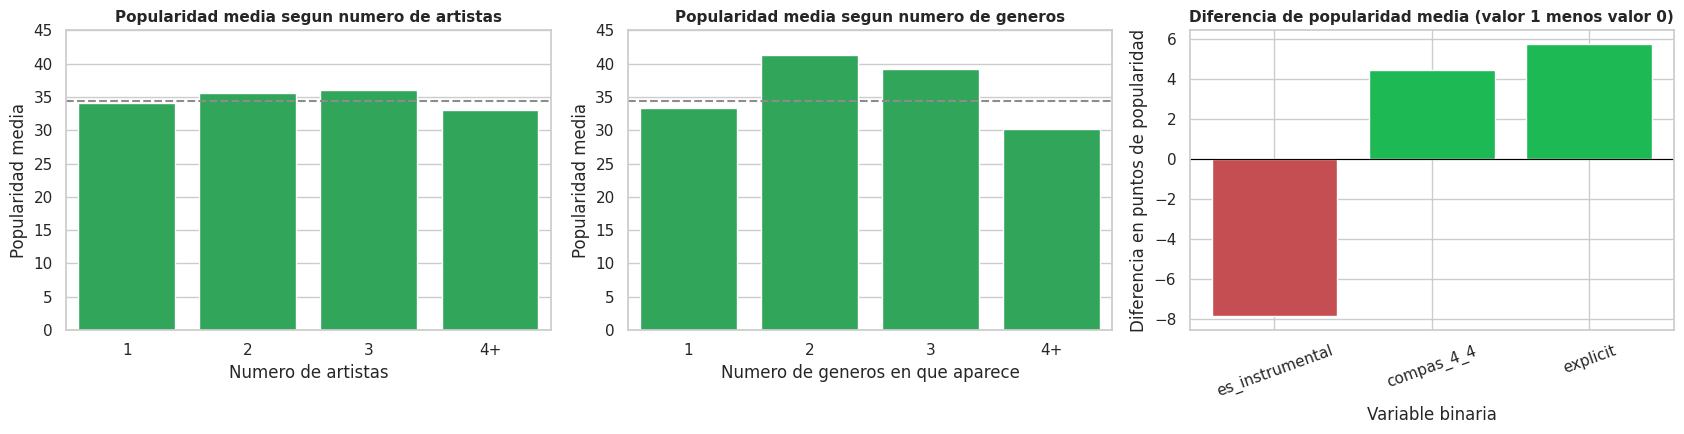

Numero de artistas (4 = 4 o mas):
             mean   size
n_artistas              
1          34.000  64176
2          35.600  15167
3          36.100   4472
4          33.000   2044

Numero de generos (4 = 4 o mas):
            mean   size
n_generos              
1         33.300  71495
2         41.300  10439
3         39.200   2581
4         30.200   1344

          variable  diferencia
0  es_instrumental      -7.860
1       compas_4_4       4.450
2         explicit       5.740


In [ ]:
# ¿Las variables nuevas se relacionan con la popularidad?
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

n_artistas_grupo = df_prep['n_artistas'].clip(upper=4)  # 4 representa "4 o mas" solo para el grafico
medias_artistas = df_prep.groupby(n_artistas_grupo)['popularity'].agg(['mean', 'size'])
sns.barplot(x=['1', '2', '3', '4+'], y=medias_artistas['mean'].values, color=COLOR_OBJETIVO, ax=axes[0])
axes[0].set_title('Popularidad media segun numero de artistas')
axes[0].set_xlabel('Numero de artistas')
axes[0].set_ylabel('Popularidad media')

n_generos_grupo = df_prep['n_generos'].clip(upper=4)
medias_generos = df_prep.groupby(n_generos_grupo)['popularity'].agg(['mean', 'size'])
sns.barplot(x=['1', '2', '3', '4+'], y=medias_generos['mean'].values, color=COLOR_OBJETIVO, ax=axes[1])
axes[1].set_title('Popularidad media segun numero de generos')
axes[1].set_xlabel('Numero de generos en que aparece')
axes[1].set_ylabel('Popularidad media')
for ax in axes[:2]:
    ax.set_ylim(0, 45)
    ax.axhline(df_prep['popularity'].mean(), color=COLOR_NEUTRO, linestyle='--')

# Diferencia de medias: popularidad media cuando la variable vale 1 menos cuando vale 0
variables_binarias = ['es_instrumental', 'compas_4_4', 'explicit']
diferencias = []
for variable in variables_binarias:
    medias_binaria = df_prep.groupby(variable)['popularity'].mean()
    diferencias.append(medias_binaria[1] - medias_binaria[0])
binarias = pd.DataFrame({'variable': variables_binarias, 'diferencia': diferencias})
colores = [COLOR_OBJETIVO if d > 0 else COLOR_ALERTA for d in binarias['diferencia']]
axes[2].bar(binarias['variable'], binarias['diferencia'], color=colores)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Diferencia de popularidad media (valor 1 menos valor 0)')
axes[2].set_xlabel('Variable binaria')
axes[2].set_ylabel('Diferencia en puntos de popularidad')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
print('Numero de artistas (4 = 4 o mas):')
print(medias_artistas.round(1))
print('\nNumero de generos (4 = 4 o mas):')
print(medias_generos.round(1))
print()
print(binarias.round(2))

**Interpretacion.**

- **`es_instrumental`** es la variable binaria con mayor diferencia: las canciones instrumentales (19% del total) tienen **7,7 puntos menos** de popularidad media.
- **`compas_4_4`** (+4,7 puntos) y **`explicit`** (+4,6 puntos) tambien muestran diferencias claras.
- **`n_generos`** tiene una relacion no lineal:
  - Las canciones que aparecen en 2 generos (41,3 puntos) o 3 generos (39,2) son claramente mas populares que las de un solo genero (33,2).
  - Las que aparecen en 4 o mas generos bajan a 30,2.

  Una explicacion plausible es que las busquedas de Spotify priorizan canciones populares, por lo que una cancion conocida aparece en los resultados de generos vecinos. Este posible artefacto del proceso de recoleccion se discute en la seccion 5.1.
- **`n_artistas`** tiene un efecto pequeño: las colaboraciones de 2 o 3 artistas superan en 2 puntos a las canciones de un solo artista.
- **Descartada:** tambien se evaluo una variable "grabacion en vivo" (`liveness > 0,8`), pero su diferencia de popularidad fue de apenas 1 punto y su informacion ya esta contenida en `liveness`, por lo que no se incluyo.

## 4.8 Seleccion de variables y multicolinealidad

Las decisiones de esta seccion se apoyan en la verificacion de multicolinealidad posterior a la ingenieria de caracteristicas. En una primera version se conservaron `instrumentalness` y `es_instrumental` a la vez, y el VIF de ambas supero 13 (multicolinealidad severa), algo esperable porque la segunda se deriva directamente de la primera.

| Variable | Decision | Justificacion |
|---|---|---|
| `track_id`, `album_name` | Excluir | Identificador y texto libre sin valor predictivo generalizable |
| `artists`, `track_name` | Excluir del modelo | Se usan para agrupar la division (4.9) y en el analisis de sesgos (5.2) |
| `duration_ms` | Reemplazar | Sustituida por `duracion_min` |
| `time_signature` | Reemplazar | Sustituida por `compas_4_4` |
| `instrumentalness` | Excluir | Redundante con `es_instrumental` (VIF > 13). Se conserva la version binaria porque la variable es bimodal y porque la diferencia de popularidad se explica por la distincion con voz / sin voz (seccion 3.5) |
| `key` | Excluir | n^2 = 0,0006: sin relacion con la popularidad, y su one-hot agregaria 11 columnas |
| `energy`, `loudness`, `acousticness` | Conservar | Correlacionadas entre si (hasta 0,76), pero con VIF < 5; cada una aporta un matiz propio |

In [ ]:
# Variables que se excluyen del conjunto de modelado
excluir = {
    'track_id': 'Identificador; se conserva aparte para trazabilidad',
    'artists': 'Texto libre de alta cardinalidad; se usa solo para agrupar la division y en el analisis de sesgos',
    'album_name': 'Texto libre de alta cardinalidad',
    'track_name': 'Texto libre de alta cardinalidad; se usa solo para agrupar la division',
    'duration_ms': 'Reemplazada por duracion_min',
    'time_signature': 'Reemplazada por compas_4_4',
    'instrumentalness': 'Multicolinealidad con es_instrumental (VIF > 13); se conserva la version binaria',
    'key': 'Sin relacion con la popularidad (n^2 = 0,0006) y requeriria 11 columnas one-hot',
}
for variable, razon in excluir.items():
    print(f'{variable:15s} -> {razon}')

# Tabla auxiliar con los identificadores (misma fila que df_prep)
df_ids = df_prep[['track_id', 'artists', 'track_name', 'album_name']].copy()

df_modelo = df_prep.drop(columns=[c for c in excluir if c in df_prep.columns])
print(f'\nColumnas del conjunto de modelado ({df_modelo.shape[1]}):')
print(df_modelo.columns.tolist())

track_id        -> Identificador; se conserva aparte para trazabilidad
artists         -> Texto libre de alta cardinalidad; se usa solo para agrupar la division y en el analisis de sesgos
album_name      -> Texto libre de alta cardinalidad
track_name      -> Texto libre de alta cardinalidad; se usa solo para agrupar la division
duration_ms     -> Reemplazada por duracion_min
time_signature  -> Reemplazada por compas_4_4
instrumentalness -> Multicolinealidad con es_instrumental (VIF > 13); se conserva la version binaria
key             -> Sin relacion con la popularidad (n^2 = 0,0006) y requeriria 11 columnas one-hot

Columnas del conjunto de modelado (17):
['popularity', 'explicit', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo', 'track_genre', 'n_generos', 'duracion_min', 'n_artistas', 'es_instrumental', 'compas_4_4']


In [ ]:
# Verificacion de multicolinealidad con las variables numericas finales
numericas_finales = [c for c in df_modelo.columns if c not in ['popularity', 'track_genre']]
calcular_vif(df_modelo[numericas_finales])

energy            4.344
loudness          3.169
acousticness      2.505
valence           1.601
danceability      1.601
es_instrumental   1.398
speechiness       1.169
compas_4_4        1.148
explicit          1.122
liveness          1.100
tempo             1.093
duracion_min      1.065
mode              1.024
n_artistas        1.022
n_generos         1.019
Name: VIF, dtype: float64

**Interpretacion.** Con el conjunto final, todas las variables tienen VIF menor a 5. El maximo es `energy` (4,34) y le sigue `loudness` (3,17). La multicolinealidad quedo controlada sin eliminar informacion relevante.

## 4.9 Division en entrenamiento y prueba (agrupada)

Aunque ya hay una fila por `track_id`, todavia existen versiones distintas de una misma cancion (mismo artista y titulo, seccion 2.8.4). Con una division aleatoria simple, una version podria quedar en entrenamiento y otra en prueba, y el modelo seria evaluado sobre canciones que en la practica ya vio.

Por eso se usa `GroupShuffleSplit`, que asigna **todas las filas de un mismo grupo** (artista + titulo) al mismo conjunto. Se reserva el 20% para prueba.

In [ ]:
# Grupo = misma cancion (artista + titulo), sin distinguir mayusculas
grupos = (df_ids['artists'].str.lower() + ' || ' + df_ids['track_name'].str.lower())

X = df_modelo.drop(columns='popularity')
y = df_modelo['popularity']

divisor = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEMILLA)
indices_train, indices_test = next(divisor.split(X, y, groups=grupos))

X_train = X.iloc[indices_train].copy()
X_test = X.iloc[indices_test].copy()
y_train = y.iloc[indices_train].copy()
y_test = y.iloc[indices_test].copy()

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Proporcion de prueba: {len(X_test) / len(X):.3f}')

# Verificacion: ningun grupo debe estar en ambos conjuntos
grupos_compartidos = set(grupos.iloc[indices_train]) & set(grupos.iloc[indices_test])
print(f'Grupos presentes en train y test: {len(grupos_compartidos)}')

# Verificacion: la distribucion del objetivo debe ser similar en ambos conjuntos
print(pd.DataFrame({'train': y_train.describe(), 'test': y_test.describe()}).T.round(2))

X_train: (68704, 16) | X_test: (17155, 16)
Proporcion de prueba: 0.200
Grupos presentes en train y test: 0
          count   mean    std   min    25%    50%    75%     max
train 68704.000 34.320 20.050 0.000 20.000 35.000 49.000  99.000
test  17155.000 34.670 20.140 0.000 20.000 35.000 50.000 100.000


**Interpretacion.**

- **Tamaños.** La division dejo 68.704 canciones en entrenamiento y 17.155 en prueba, exactamente 20%.
- **Sin fuga por versiones.** Ningun grupo (artista + titulo) esta en ambos conjuntos, por lo que las versiones de una misma cancion no se filtran entre ellos.
- **Objetivo equilibrado.** La distribucion de `popularity` es practicamente identica en ambos conjuntos (media 34,32 vs 34,67; mismos cuartiles), por lo que no fue necesaria una estratificacion adicional.

## 4.10 Codificacion de `track_genre`

`track_genre` es la variable categorica con mayor poder explicativo (n^2 de la seccion 3.6), pero tiene mas de 100 categorias.

| Alternativa | Problema |
|---|---|
| Label encoding (1, 2, 3...) | Impone un orden numerico que no existe entre generos |
| One-hot encoding | Crea mas de 100 columnas binarias muy dispersas |
| **Target encoding** | Reemplaza cada genero por la popularidad media de ese genero: una sola columna con significado directo |

Se usa `TargetEncoder` de scikit-learn por dos razones que evitan la fuga de datos:

1. **Se ajusta solo con entrenamiento.** La popularidad del conjunto de prueba nunca interviene en su propia codificacion.
2. **Usa validacion cruzada interna (*cross fitting*) en `fit_transform`.** Cada fila de entrenamiento se codifica con medias calculadas en los *otros* pliegues, por lo que la popularidad de una cancion no se filtra en su propia variable. Ademas aplica suavizado hacia la media global para los generos con pocas canciones.

In [ ]:
codificador_genero = TargetEncoder(target_type='continuous', smooth='auto', cv=5,
                                   shuffle=True, random_state=SEMILLA)

# En train: fit_transform con cross fitting (evita fuga dentro del propio entrenamiento)
X_train['genero_codificado'] = codificador_genero.fit_transform(X_train[['track_genre']], y_train).ravel()
# En test: solo transform, con las medias aprendidas en train
X_test['genero_codificado'] = codificador_genero.transform(X_test[['track_genre']]).ravel()

# Se conserva la etiqueta original aparte (se usa en el analisis de sesgos) y se elimina de X
genero_train = X_train.pop('track_genre')
genero_test = X_test.pop('track_genre')

print(X_train['genero_codificado'].describe().round(2))
print(f"\nCorrelacion genero_codificado vs popularity (train): "
      f"{np.corrcoef(X_train['genero_codificado'], y_train)[0, 1]:.3f}")

count   68704.000
mean       34.320
std        11.890
min         2.200
25%        26.200
50%        36.120
75%        42.710
max        59.210
Name: genero_codificado, dtype: float64

Correlacion genero_codificado vs popularity (train): 0.590


**Interpretacion.**

- **Rango.** `genero_codificado` va de 2,2 a 59,2 puntos, con media 34,3, igual a la popularidad media de entrenamiento.
- **Poder predictivo.** Su correlacion con la popularidad en entrenamiento es 0,590. Es, por lejos, la variable individual mas relacionada con el objetivo, y la cifra es coherente con el n^2 del genero (0,326 aprox. 0,57^2).
- **Sin sobreestimacion.** Gracias al *cross fitting*, esa correlacion no esta inflada por la propia popularidad de cada cancion.

## 4.11 Transformacion y escalado

**Transformacion.** Las variables con asimetria absoluta mayor a 1 en entrenamiento se transforman con **Yeo-Johnson** (`PowerTransformer`). Se elige Yeo-Johnson y no el logaritmo porque admite ceros (presentes en `speechiness`, `acousticness`, etc.) y busca automaticamente la potencia que hace la distribucion mas simetrica. No se transforman las variables binarias, porque solo tienen dos valores y su asimetria refleja la proporcion de cada clase, no una cola larga.

**Escalado.** Las variables tienen escalas muy distintas: `tempo` ronda 120, `loudness` es negativa, `duracion_min` va de segundos a mas de una hora y la mayoria de las caracteristicas de audio esta entre 0 y 1. Los modelos basados en distancias o en coeficientes regularizados (KNN, Ridge, Lasso) darian mas peso a las variables con valores grandes, por lo que se aplica `StandardScaler` (media 0, desviacion 1) a todas las variables continuas. Las variables binarias se dejan en 0/1 porque ya estan en una escala comparable y conservan su interpretacion. La variable objetivo no se transforma: su distribucion es razonablemente simetrica y su escala (0-100) es interpretable.

In [ ]:
columnas_binarias = ['explicit', 'mode', 'es_instrumental', 'compas_4_4']
columnas_continuas_final = [c for c in X_train.columns if c not in columnas_binarias]

# Asimetria calculada SOLO con train
asimetria_train = X_train[columnas_continuas_final].skew()
columnas_asimetricas = asimetria_train[asimetria_train.abs() > 1].index.tolist()
print('Variables a transformar con Yeo-Johnson:', columnas_asimetricas)

transformador = PowerTransformer(method='yeo-johnson', standardize=False)
X_train[columnas_asimetricas] = transformador.fit_transform(X_train[columnas_asimetricas])
X_test[columnas_asimetricas] = transformador.transform(X_test[columnas_asimetricas])

comparacion_asimetria = pd.DataFrame({
    'antes': asimetria_train[columnas_asimetricas],
    'despues': X_train[columnas_asimetricas].skew(),
})
comparacion_asimetria

Variables a transformar con Yeo-Johnson: ['loudness', 'speechiness', 'liveness', 'n_generos', 'duracion_min', 'n_artistas']


,antes,despues
loudness,-1.938,0.141
speechiness,2.807,0.630
liveness,2.122,0.370
n_generos,3.346,1.785
duracion_min,11.742,-0.044
n_artistas,6.636,1.145


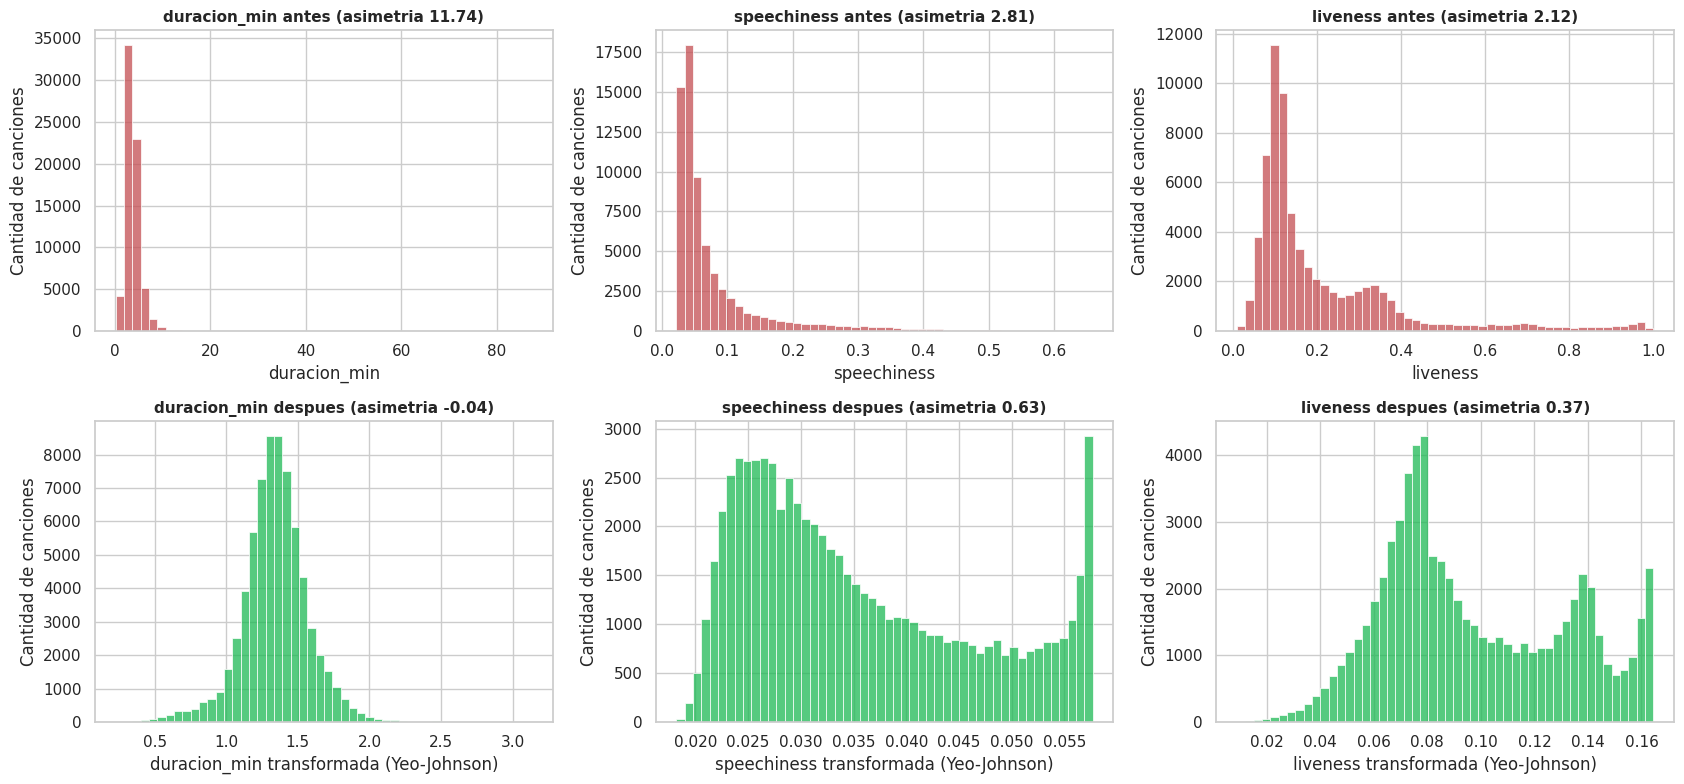

In [ ]:
# Se muestran las tres variables continuas de audio mas asimetricas (fila superior: antes; inferior: despues)
variables_grafico = ['duracion_min', 'speechiness', 'liveness']
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for i, col in enumerate(variables_grafico):
    sns.histplot(X.iloc[indices_train][col], bins=50, color=COLOR_ALERTA, ax=axes[0, i])
    axes[0, i].set_title(f'{col} antes (asimetria {comparacion_asimetria.loc[col, "antes"]:.2f})')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Cantidad de canciones')
    sns.histplot(X_train[col], bins=50, color=COLOR_OBJETIVO, ax=axes[1, i])
    axes[1, i].set_title(f'{col} despues (asimetria {comparacion_asimetria.loc[col, "despues"]:.2f})')
    axes[1, i].set_xlabel(f'{col} transformada (Yeo-Johnson)')
    axes[1, i].set_ylabel('Cantidad de canciones')
plt.tight_layout()
plt.show()

In [ ]:
escalador = StandardScaler()
X_train[columnas_continuas_final] = escalador.fit_transform(X_train[columnas_continuas_final])
X_test[columnas_continuas_final] = escalador.transform(X_test[columnas_continuas_final])

# En train las medias deben ser 0 y las desviaciones 1; en test seran cercanas, no exactas
verificacion_escala = pd.DataFrame({
    'media_train': X_train[columnas_continuas_final].mean(),
    'desv_train': X_train[columnas_continuas_final].std(),
    'media_test': X_test[columnas_continuas_final].mean(),
    'desv_test': X_test[columnas_continuas_final].std(),
})
verificacion_escala.round(3)

,media_train,desv_train,media_test,desv_test
danceability,-0.000,1.000,0.012,0.982
energy,0.000,1.000,-0.002,0.993
loudness,0.000,1.000,-0.004,0.981
speechiness,0.000,1.000,-0.007,0.999
acousticness,0.000,1.000,0.004,0.998
liveness,-0.000,1.000,0.009,1.006
valence,-0.000,1.000,0.023,0.996
tempo,0.000,1.000,0.004,0.987
n_generos,-0.000,1.000,0.003,1.003
duracion_min,-0.000,1.000,-0.000,0.979


**Interpretacion.**

- **Transformacion Yeo-Johnson.**
  - Redujo la asimetria de `duracion_min` de 11,7 a -0,04 y de `liveness` de 2,1 a 0,4.
  - `speechiness` bajo de 2,8 a 0,6. Su asimetria de partida ya es mas baja que en el archivo original (que rondaba 4,5): al haber eliminado las 868 filas de contenido casi enteramente hablado (seccion 4.4), la cola mas extrema de esta variable ya no esta en el conjunto de entrenamiento.
  - `loudness` paso de -1,9 a 0,1.
  - En `liveness`, la transformacion comprime la cola larga en un grupo separado en el extremo derecho, que corresponde a grabaciones en vivo. El orden entre canciones se conserva, pero esos valores ya no quedan a una distancia desproporcionada del resto, que era el objetivo.
  - `n_generos` (1,8) y `n_artistas` (1,1) siguen algo asimetricas porque son conteos con la mayoria de sus valores en 1; ninguna transformacion continua puede repartir valores identicos. Su escala quedo igualmente acotada.
- **Escalado.**
  - En entrenamiento, todas las variables continuas tienen media 0 y desviacion 1.
  - En prueba, los valores se mantienen muy cercanos (medias entre -0,007 y 0,023; desviaciones entre 0,98 y 1,01). Esto confirma que ambos conjuntos provienen de la misma distribucion y que el escalador no aprendio de los datos de prueba.

## 4.12 Verificacion final, linea base y exportacion

In [ ]:
print('=== Verificacion del dataset final ===')
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Nulos en X_train / X_test: {X_train.isnull().sum().sum()} / {X_test.isnull().sum().sum()}')
print(f'Columnas no numericas: {X_train.select_dtypes(exclude="number").columns.tolist()}')
print(f'Mismas columnas y en el mismo orden: {list(X_train.columns) == list(X_test.columns)}')
print(f'\nFilas: archivo original {len(df):,} -> dataset final {len(X_train) + len(X_test):,} '
      f'({(len(X_train) + len(X_test)) / len(df) * 100:.1f}%)')
print('\nColumnas finales:', X_train.columns.tolist())
X_train.head()

=== Verificacion del dataset final ===
X_train: (68704, 16) | X_test: (17155, 16)
Nulos en X_train / X_test: 0 / 0
Columnas no numericas: []
Mismas columnas y en el mismo orden: True

Filas: archivo original 114,000 -> dataset final 85,859 (75.3%)

Columnas finales: ['explicit', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo', 'n_generos', 'duracion_min', 'n_artistas', 'es_instrumental', 'compas_4_4', 'genero_codificado']


,explicit,danceability,energy,loudness,mode,speechiness,acousticness,liveness,valence,tempo,n_generos,duracion_min,n_artistas,es_instrumental,compas_4_4,genero_codificado
0,0,-0.798,-1.818,-1.590,1,0.557,1.777,-0.699,-0.759,-1.518,2.226,-0.920,-0.581,0,1,0.743
1,0,-0.696,-1.069,-0.476,1,-0.028,-0.339,-0.471,-1.317,-1.557,-0.448,-0.045,1.671,0,1,0.674
2,0,-1.669,-2.231,-1.737,1,-0.808,1.721,-0.277,-1.229,1.995,-0.448,-0.157,-0.581,0,0,0.743
3,0,0.322,-0.743,-0.465,1,-0.136,0.429,-0.987,-1.138,-0.087,-0.448,-0.197,-0.581,0,1,0.674
4,0,0.803,-0.739,-0.397,1,-0.564,0.696,-0.755,0.931,0.958,2.226,0.325,-0.581,0,1,0.674


In [ ]:
# Linea base: un modelo que siempre predice la popularidad media de entrenamiento.
# Estos valores son la referencia para los KPIs relativos definidos en la seccion 1.5.
baseline = DummyRegressor(strategy='mean').fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

mae_base = mean_absolute_error(y_test, pred_baseline)
rmse_base = np.sqrt(mean_squared_error(y_test, pred_baseline))
alta = y_test >= 70
print('=== Linea base (predice la media) sobre test ===')
print(f'MAE  : {mae_base:.2f}  -> umbral KPI (80%): {0.80 * mae_base:.2f}')
print(f'RMSE : {rmse_base:.2f}  -> umbral KPI (77%): {0.77 * rmse_base:.2f}')
print(f'R^2   : {r2_score(y_test, pred_baseline):.4f}')
print(f'MAE en canciones con popularity >= 70 ({alta.sum()} canciones): '
      f'{mean_absolute_error(y_test[alta], pred_baseline[alta]):.2f}')

=== Linea base (predice la media) sobre test ===
MAE  : 16.83  -> umbral KPI (80%): 13.46
RMSE : 20.15  -> umbral KPI (77%): 15.51
R^2   : -0.0003
MAE en canciones con popularity >= 70 (657 canciones): 41.19


In [ ]:
# Equidad: ¿como se reparte el error de la linea base entre grupos de generos?
# Se agrupan los generos de test en cuartiles segun el valor que aprendio el TargetEncoder
# (seccion 4.10), que resume la popularidad promedio de cada genero en entrenamiento.
valores_codificados = pd.Series(codificador_genero.encodings_[0],
                                index=codificador_genero.categories_[0])
cuartil_genero = pd.qcut(genero_test.map(valores_codificados), q=4,
                         labels=['Q1 (menos populares)', 'Q2', 'Q3', 'Q4 (mas populares)'])
error_baseline = (y_test - pred_baseline).abs()
equidad_baseline = error_baseline.groupby(cuartil_genero, observed=True).agg(['mean', 'size'])
equidad_baseline.columns = ['MAE baseline', 'canciones test']
print(equidad_baseline.round(2))
print(f"\nBrecha de MAE entre cuartiles: "
      f"{equidad_baseline['MAE baseline'].max() - equidad_baseline['MAE baseline'].min():.2f} puntos "
      f"-> umbral KPI: <= 5 puntos")

                      MAE baseline  canciones test
track_genre                                       
Q1 (menos populares)        19.090            4333
Q2                          14.020            4345
Q3                          14.190            4286
Q4 (mas populares)          20.090            4191

Brecha de MAE entre cuartiles: 6.08 puntos -> umbral KPI: <= 5 puntos


La linea base ya comete errores desiguales entre grupos de generos: el MAE es mayor tanto en los generos menos populares (Q1) como en los mas populares (Q4), y menor en los intermedios (Q2 y Q3). Esa brecha inicial supera el umbral de 5 puntos definido en el KPI de equidad de la seccion 1.5, asi que el modelo de la siguiente etapa debera reducirla y reportar su error por cuartil de genero, no solo como un numero global.

Los conjuntos `X_train`, `X_test`, `y_train` y `y_test`, junto con los objetos ya ajustados
(`codificador_genero`, `transformador`, `escalador`), quedan disponibles en memoria para la
etapa de modelado dentro de esta misma sesion de Colab.

### Resumen del preprocesamiento

| Paso | Filas afectadas | Filas restantes |
|---|---|---|
| Archivo original | - | 114.000 |
| Fila con nulos | -1 | 113.999 |
| Duplicados exactos | -450 | 113.549 |
| Unificacion `songwriter` | -1.000 | 112.549 |
| Una fila por cancion | -22.809 | 89.740 |
| `tempo = 0` | -157 | 89.583 |
| Contenido casi enteramente hablado (`speechiness > 0,66`) | -868 | 88.715 |
| Versiones con popularidad 0 artificial | -2.856 | **85.859** |

**Resultado del preprocesamiento:**

- **Dataset final:** 85.859 canciones (75,3% del archivo original). La mayor parte de la reduccion corresponde a filas repetidas, no a informacion perdida; la unica perdida de contenido deliberada es el material casi enteramente hablado.
- **Division:** 68.704 canciones de entrenamiento y 17.155 de prueba, con **16 variables** numericas, sin nulos y sin fuga de datos.
  - 11 continuas escaladas: 8 de audio, `n_generos`, `n_artistas` y `duracion_min`.
  - 4 binarias: `explicit`, `mode`, `es_instrumental` y `compas_4_4`.
  - 1 genero codificado por objetivo.
- **Referencia para los KPIs** (linea base que predice la media): MAE 16,83 y RMSE 20,15 en prueba.
  - El modelo de la siguiente etapa debera alcanzar MAE <= 13,46 y RMSE <= 15,51.
  - En el segmento de alta popularidad, la linea base comete un error de 41,2 puntos.
- **Disponibilidad para el modelado.** `X_train`, `X_test`, `y_train`, `y_test`, y los objetos ajustados con entrenamiento (`codificador_genero`, `transformador`, `escalador`) quedan en memoria, listos para usarse en la siguiente etapa dentro de la misma sesion.

---
# 5. Sesgos, etica y privacidad

El analisis se hace sobre los datos, antes de entrenar cualquier modelo: el objetivo es identificar que sesgos ya estan presentes y serian heredados por cualquier algoritmo entrenado con ellos. Se usa `df_prep` (datos limpios, una fila por cancion, sin codificar), que conserva artistas y generos.

| Tipo de sesgo | Pregunta |
|---|---|
| Muestreo / construccion | ¿Representa el dataset al catalogo real de Spotify? |
| Concentracion (efecto superestrella) | ¿La popularidad depende de quien es el artista mas que de la cancion? |
| Factores no observados y alcance de Spotify | ¿Que le falta a este dataset para explicar la popularidad? |

## 5.1 Sesgo de muestreo y de construccion

In [ ]:
conteo_final_genero = df_prep['track_genre'].value_counts()
print('Canciones por genero en el archivo original: exactamente', canciones_por_genero.min(), 'en cada uno')
print(f'Canciones por genero tras la limpieza: min {conteo_final_genero.min()} '
      f'({conteo_final_genero.idxmin()}) | max {conteo_final_genero.max()} ({conteo_final_genero.idxmax()})')

# Generos que perdieron mas canciones por solaparse con otros
perdida = (1 - conteo_final_genero / canciones_por_genero.reindex(conteo_final_genero.index)) * 100
print('\nGeneros con mayor perdida de canciones (%):')
print(perdida.sort_values(ascending=False).head(6).round(1))

Canciones por genero en el archivo original: exactamente 1000 en cada uno
Canciones por genero tras la limpieza: min 229 (comedy) | max 1000 (tango)

Generos con mayor perdida de canciones (%):
track_genre
comedy        77.100
reggaeton     69.100
reggae        68.400
alternative   65.900
edm           65.800
latino        64.100
Name: count, dtype: float64


**Interpretacion.**

- **Diseño balanceado artificial.** El dataset se construyo con exactamente 1.000 canciones por genero. Esa distribucion no representa el catalogo de Spotify, donde el pop o el reggaeton tienen muchas mas canciones y oyentes que el `detroit-techno` o el `honky-tonk`. Un modelo entrenado aqui ve tanta musica clasica como pop, lo que distorsiona cualquier estimacion "promedio".
- **Desbalance tras la limpieza.** Los generos de mayor alcance comercial son los que mas canciones comparten con otros, y por eso son los mas afectados por la deduplicacion: `reggaeton` perdio el 69% de sus canciones, `reggae` el 68%, `alternative` y `edm` el 66%, y `latino` el 64%. En cambio, `tango` conserva sus 1.000 canciones. El resultado es que **los generos masivos terminan subrepresentados** frente a los de nicho.
- **Un caso distinto: `comedy`.** Es el genero que mas canciones perdio en total (77%), pero por una razon diferente a la deduplicacion: la mayoria de sus filas se elimino en la seccion 4.4 por ser contenido casi enteramente hablado (`speechiness > 0,66`), no por compartir canciones con otros generos. Es una perdida deliberada y justificada, no un efecto colateral del muestreo.
- **Seleccion por busqueda.** Las canciones no son una muestra aleatoria: son las que la busqueda de Spotify devolvio para cada genero. Esa busqueda favorece contenido popular, lo que explica que las canciones presentes en varios generos tengan mayor popularidad (seccion 4.7). `n_generos` debe interpretarse con cautela, porque en parte es un **artefacto del proceso de recoleccion**, no una caracteristica musical.

## 5.2 Sesgo de concentracion: el efecto del artista

La popularidad en streaming depende fuertemente de la base de oyentes del artista. Si eso ocurre, un modelo basado en audio podria aprender, de forma indirecta, "a quien se parece" una cancion mas que su calidad musical.

In [ ]:
# Artista principal = el primero de la lista
artista_principal = df_prep['artists'].str.split(';').str[0]
canciones_artista = artista_principal.value_counts()

print(f'Artistas principales distintos: {canciones_artista.size:,}')
print(f'Artistas con una sola cancion : {(canciones_artista == 1).sum():,} '
      f'({(canciones_artista == 1).mean() * 100:.1f}%)')
top_1pct = canciones_artista.head(int(len(canciones_artista) * 0.01))
print(f'El 1% de artistas con mas canciones concentra el {top_1pct.sum() / len(df_prep) * 100:.1f}% del dataset')

# ¿Cuanta varianza de la popularidad explica el artista y cuanta el genero?
# Con muchas categorias pequeñas, n^2 sube aunque no exista relacion real (un artista con una
# sola cancion "explica" su propia popularidad). Para dimensionar ese efecto se calcula tambien
# n^2 con la popularidad desordenada al azar, que representa el nivel esperable por casualidad.
datos_sesgo = df_prep.assign(artista=artista_principal)
datos_azar = datos_sesgo.assign(popularity=datos_sesgo['popularity'].sample(frac=1, random_state=SEMILLA).values)

eta_comparacion = pd.DataFrame({
    'n^2 observado': [eta_cuadrado(datos_sesgo, 'artista'), eta_cuadrado(datos_sesgo, 'track_genre')],
    'n^2 al azar': [eta_cuadrado(datos_azar, 'artista'), eta_cuadrado(datos_azar, 'track_genre')],
}, index=['Artista principal', 'Genero'])
eta_comparacion['exceso sobre el azar'] = eta_comparacion['n^2 observado'] - eta_comparacion['n^2 al azar']
print()
print(eta_comparacion.round(3))

Artistas principales distintos: 17,474
Artistas con una sola cancion : 7,136 (40.8%)
El 1% de artistas con mas canciones concentra el 15.3% del dataset



                   n^2 observado  n^2 al azar  exceso sobre el azar
Artista principal          0.713        0.204                 0.509
Genero                     0.351        0.001                 0.350


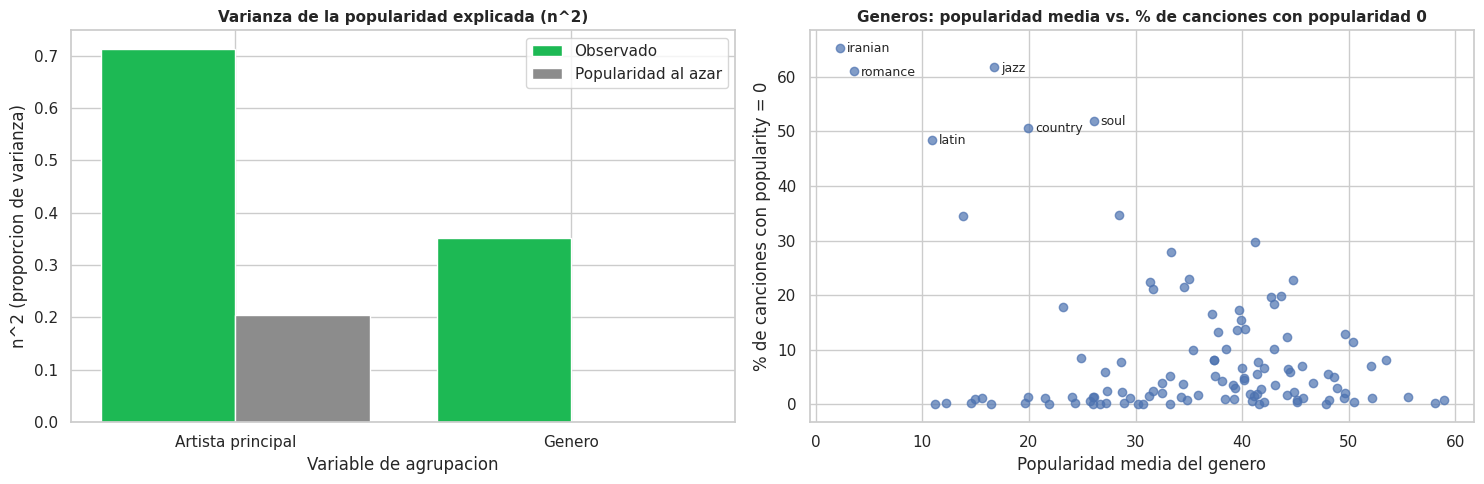

          mean   size
artists              
1       38.600   7136
2-5     36.000  19607
6-20    34.000  29935
>20     32.700  29181

Artistas con mas canciones en el dataset:
  George Jones               332 canciones | genero principal: honky-tonk   | popularidad media: 16.1
  Wolfgang Amadeus Mozart    304 canciones | genero principal: classical    | popularidad media: 10.5
  Pritam                     302 canciones | genero principal: indian       | popularidad media: 53.1
  Hank Williams              243 canciones | genero principal: honky-tonk   | popularidad media: 17.1


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Varianza explicada por artista y por genero, frente al nivel esperable por azar
eta_grafico = eta_comparacion[['n^2 observado', 'n^2 al azar']]
posiciones = np.arange(len(eta_grafico))
axes[0].bar(posiciones - 0.2, eta_grafico['n^2 observado'], width=0.4, color=COLOR_OBJETIVO, label='Observado')
axes[0].bar(posiciones + 0.2, eta_grafico['n^2 al azar'], width=0.4, color=COLOR_NEUTRO, label='Popularidad al azar')
axes[0].set_xticks(posiciones)
axes[0].set_xticklabels(eta_grafico.index)
axes[0].set_title('Varianza de la popularidad explicada (n^2)')
axes[0].set_xlabel('Variable de agrupacion')
axes[0].set_ylabel('n^2 (proporcion de varianza)')
axes[0].legend()

# Genero: popularidad media vs. porcentaje de canciones con popularidad 0
resumen_genero = df_prep.groupby('track_genre').agg(
    popularidad=('popularity', 'mean'),
    pct_cero=('popularity', lambda s: (s == 0).mean() * 100))
axes[1].scatter(resumen_genero['popularidad'], resumen_genero['pct_cero'], color=COLOR_AUDIO, alpha=0.7)
# Se rotulan solo los generos con mayor % de ceros para no saturar el grafico
for genero, fila in resumen_genero.nlargest(6, 'pct_cero').iterrows():
    axes[1].annotate(genero, (fila['popularidad'], fila['pct_cero']), fontsize=9,
                     xytext=(5, -3), textcoords='offset points')
axes[1].set_title('Generos: popularidad media vs. % de canciones con popularidad 0')
axes[1].set_xlabel('Popularidad media del genero')
axes[1].set_ylabel('% de canciones con popularity = 0')

plt.tight_layout()
plt.show()

# Popularidad segun cuantas canciones tiene el artista en el dataset
tramo_catalogo = pd.cut(artista_principal.map(canciones_artista), bins=[0, 1, 5, 20, 1000],
                        labels=['1', '2-5', '6-20', '>20'])
print(df_prep.groupby(tramo_catalogo, observed=True)['popularity'].agg(['mean', 'size']).round(1))
print('\nArtistas con mas canciones en el dataset:')
for artista in canciones_artista.head(4).index:
    filas_artista = df_prep[artista_principal == artista]
    print(f'  {artista:25s} {len(filas_artista):>4} canciones | genero principal: '
          f'{filas_artista["track_genre"].mode()[0]:12s} | popularidad media: {filas_artista["popularity"].mean():.1f}')

**Interpretacion.**

- **El artista explica mas que el genero.** El artista principal explica el 71,3% de la varianza de la popularidad. Como hay muchos artistas con una sola cancion (40,8%), una parte de esa cifra es mecanica: con la popularidad desordenada al azar, el artista aun "explica" un 20,4%. Descontado ese efecto, **el exceso sobre el azar es de 0,51, frente a 0,35 del genero**. Saber quien interpreta una cancion dice mas sobre su popularidad que su genero o su sonido.
- **Implicancia etica.** El modelo planteado no usa el artista como variable, pero las caracteristicas de audio pueden funcionar como una "huella" del estilo de artistas consolidados. Existe el riesgo de que el modelo aprenda a reconocer a quien se parece una cancion, reforzando el **efecto superestrella**: se predice exito para lo que suena como lo que ya es exitoso, y los artistas emergentes con propuestas distintas quedan subestimados.
- **Composicion del dataset.** Los artistas con mas canciones no son superestrellas actuales, sino catalogos amplios de nicho (George Jones y Hank Williams en `honky-tonk`, Mozart en `classical`), con popularidades medias de 10 a 17 puntos. Por eso la popularidad media baja a medida que el artista tiene mas canciones (de 38,6 a 32,6): el dataset esta influido por la estructura de catalogos antiguos mas que por la dinamica actual del mercado.
- **Generos con muchos ceros.** El grafico de la derecha muestra que los generos con popularidad media baja concentran tambien el mayor porcentaje de ceros incluso despues de la limpieza: `iranian` 65%, `jazz` 62%, `romance` 61%, `soul` 52%, `country` 51% y `latin` 48%.

## 5.3 Factores no observados y alcance de Spotify

Estas dos limitaciones no se analizan con codigo porque no son un problema de calidad de los datos que se pueda medir o corregir: son limites conceptuales de lo que el dataset puede explicar.

**Factores no observados.** El dataset solo contiene caracteristicas de audio y metadatos basicos. La popularidad real de una cancion tambien depende de factores que no estan aqui: el presupuesto de marketing de la discografica, si la cancion queda en una playlist editorial de Spotify, la fama previa del artista fuera de la plataforma, campañas en redes sociales, o simplemente el momento en que se lanza. Ningun modelo entrenado solo con audio puede capturar esto, lo que pone un techo realista a que tan bien se puede predecir la popularidad (de ahi el umbral moderado del KPI de R^2 en la seccion 1.5).

**Alcance de Spotify.** La popularidad que mide este dataset es la popularidad *dentro de Spotify*, no la popularidad musical en general. Spotify tiene una penetracion de mercado muy distinta segun el pais: es dominante en gran parte de America y Europa, pero tiene menor presencia en otros mercados. Una cancion puede ser enormemente popular en su pais de origen y aun asi tener un valor bajo en esta variable, simplemente porque ahi la gente escucha musica por otros medios. Esto significa que el dataset refleja el alcance de la plataforma, no el exito real de una cancion.

## 5.4 Privacidad y condiciones de uso de los datos

**Datos personales.** El dataset no contiene informacion de usuarios: la popularidad es un indicador agregado y no permite identificar oyentes. Si contiene nombres de artistas, que son figuras publicas y cuyos datos corresponden a su actividad profesional publicada en la plataforma. No hay datos sensibles en el sentido de la Ley 19.628 sobre proteccion de la vida privada (actualizada por la Ley 21.719) ni del RGPD europeo. Aun asi, un modelo que califique a artistas individuales como "poco populares" puede afectar su reputacion o sus oportunidades comerciales, por lo que sus resultados no deberian publicarse por artista sin contexto.

**Condiciones de uso de la fuente.** Los datos provienen de la Web API de Spotify. Hay dos aspectos a considerar:

- **Terminos para desarrolladores.** Desde su version de mayo de 2023, estos terminos prohiben usar el contenido de Spotify para entrenar modelos de Machine Learning. El dataset de Kaggle se publica para fines educativos y este proyecto es academico, pero **un uso comercial del modelo requeriria revisar la licencia de los datos o un acuerdo con Spotify**.
- **Reproducibilidad.** Desde el 27 de noviembre de 2024, Spotify restringio el acceso de las nuevas aplicaciones a los endpoints de caracteristicas de audio. Esto significa que **no es posible obtener estas mismas variables para canciones nuevas** mediante la API publica, lo que limita el despliegue del modelo tal como esta planteado. Una alternativa seria calcular caracteristicas equivalentes con librerias abiertas de analisis de audio (por ejemplo, `librosa` o Essentia).

**Medidas aplicadas en el proyecto.** Los identificadores (`track_id`) y los textos (artistas, album, titulo) se excluyeron del conjunto de modelado. Solo se usan para trazabilidad, para agrupar la division de datos y para este analisis de sesgos.

## 5.5 Riesgos eticos del uso del modelo

**Desigualdad entre mercados y artistas.** Por los sesgos descritos en las secciones 5.2 y 5.3, un uso automatico del modelo perjudicaria sistematicamente a la musica no anglosajona, a los generos de nicho y a los artistas emergentes.

**Uso responsable.** La predicción debe apoyar decisiones de promoción, no reemplazar el juicio humano ni convertirse en un filtro automático para fichar o descartar artistas.

**Explicabilidad.** El modelo debe usarse como **herramienta de apoyo** a los equipos de A&R, no como decision automatica. Sus predicciones deben acompañarse del error esperado por genero (KPI de equidad) y de las variables que mas influyeron en cada estimacion, para que quien lo use entienda por que el modelo llego a un numero y pueda contrastarlo con su propio criterio.

## 5.6 Sintesis de sesgos

| Sesgo / riesgo | Evidencia cuantitativa | Medida adoptada o recomendada |
|---|---|---|
| Muestreo artificial por genero | 1.000 canciones por genero; `reggaeton` pierde 69% tras deduplicar | Seleccion aleatoria del genero conservado; documentar que el modelo no representa al catalogo real |
| Seleccion por busqueda | Canciones en 2-3 generos: +6 a +8 puntos de popularidad | Interpretar `n_generos` como artefacto; evaluar el modelo con y sin esta variable |
| Efecto superestrella | Artista: exceso de n^2 de 0,51 sobre el azar, frente a 0,35 del genero | Artista excluido del modelo; revisar errores en artistas con pocas canciones |
| Factores no observados | No es cuantificable con estos datos (marketing, playlists, fama previa) | Documentar como limitacion; fijar expectativas moderadas en los KPIs |
| Alcance de Spotify | No es cuantificable con estos datos (penetracion de mercado desigual por pais) | Documentar como limitacion del significado de `popularity` |
| Privacidad y licencia | Sin datos de usuarios; terminos de Spotify restringen el entrenamiento de modelos | Uso academico; excluir identificadores; revisar la licencia antes de un uso comercial |

---
# 6. Conclusiones y proximos pasos

## 6.1 Conclusiones

1. **La calidad de los datos era el principal desafio.** El archivo parecia limpio (solo 1 fila con nulos y "0 duplicados"), pero el analisis revelo problemas ocultos:
   - 450 duplicados escondidos por un indice exportado.
   - 24.259 filas que repetian canciones en varios generos.
   - Etiquetas de genero duplicadas.
   - Contenido no musical con tempo 0.
   - 868 filas de contenido casi enteramente hablado (comedia, no musica).
   - 2.856 versiones con popularidad 0 artificial.

   Sin tratarlos, cualquier modelo habria sido evaluado con metricas infladas por fuga de datos.
2. **La popularidad depende poco del audio y mucho del contexto.** Ninguna caracteristica de audio supera una correlacion de 0,13 con la popularidad, aunque varias muestran relaciones no lineales (forma de U invertida en energia, bailabilidad y duracion). El genero explica cerca de un tercio de la varianza, y el artista aun mas. Esto fija expectativas moderadas para el modelado y orienta la eleccion hacia modelos no lineales.
3. **El preprocesamiento es reproducible y evita la fuga de datos.** El resultado son 85.859 canciones (75% del original) con 16 variables numericas:
   - La division train/test se agrupo por cancion.
   - La codificacion del genero, las transformaciones y el escalado se ajustaron solo con entrenamiento, y quedaron en memoria listos para aplicarse a canciones nuevas.
4. **Cada decision quedo justificada con evidencia.** Los outliers se conservaron por ser variacion legitima entre generos. `key` e `instrumentalness` se eliminaron por irrelevancia y redundancia, respectivamente. Se crearon variables que resumen informacion util (`es_instrumental`, `compas_4_4`, `n_generos`, `n_artistas`).
5. **Los sesgos son relevantes y medibles.** El dataset tiene un muestreo artificial por genero y una fuerte dependencia del artista, ademas de limitaciones que no se pueden corregir con estos datos (factores no observados como marketing o playlists, y el alcance desigual de Spotify entre paises). La linea base ya muestra una brecha de error de 6,1 puntos entre grupos de generos, lo que justifica incluir un KPI de equidad en el criterio de exito del proyecto.

## 6.2 Proximos pasos

| Fase CRISP-DM | Actividad |
|---|---|
| Modelado | Entrenar un modelo lineal regularizado (Ridge) como referencia interpretable y al menos un modelo no lineal (Random Forest o Gradient Boosting), con validacion cruzada agrupada por cancion |
| Modelado | Evaluar el aporte de `n_generos` entrenando con y sin esa variable, por su posible origen en el proceso de recoleccion |
| Evaluacion | Verificar los KPIs de la seccion 1.5, incluyendo el error en canciones de alta popularidad y la brecha por cuartil de genero |
| Evaluacion | Analizar los residuos por genero y por tamaño de catalogo del artista |
| Datos | Explorar fuentes complementarias (fecha de lanzamiento, seguidores del artista) y caracteristicas de audio abiertas que no dependan de la API restringida de Spotify |
| Despliegue | Definir el modelo como herramienta de apoyo a decisiones de A&R, con reporte del error esperado por genero |